# Surrogate Modeling for Sensitivity Analysis
## AUC prediction for polarization curve regions

Running sensitivity analysis (e.g., Sobol indices) directly on the AlphaPEM simulator is computationally expensive. Each simulation run requires significant time, and evaluating global sensitivities over thousands of configurations is not feasible in practice.

To overcome this, we decided to train a surrogate model (SM) using XGBoost that can approximate the AlphaPEM outputs, specifically, the integrated voltage (AUC) in different regions of the polarization curve. If the surrogate generalizes well, then it can be used in place of AlphaPEM to compute sensitivities more efficiently.

The goal is not to interpret the model itself, but to enable efficient approximation of Sobol or Shapley-based global sensitivity indices using a fast and accurate surrogate.


In [1]:
import os
import sys
import json
import joblib
import yaml
from omegaconf import OmegaConf

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

# Scikit-learn
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from SALib.sample import saltelli
from SALib.analyze import sobol
from SALib.sample import sobol as sobol_sampler
from SALib.analyze import sobol as sobol_analyzer
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="SALib.util")
import shap

# Custom modules
sys.path.append("../external/AlphaPEM")
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.sampling.sampler import get_polarisation_curve_samples, build_fixed_parameters
from src.validity.validity_criteria import validate_polarization_curves

c:\Users\User\anaconda3\envs\env_PEM\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Region definitions

The polarization curve is split into three regions, based on current density:

In [2]:
REGIONS = {
    "activation": (0.0, 0.4),
    "ohmic": (0.4, 1.6),
    "mass_transport": (1.6, np.inf),
}

## Utils definition: Useful functions

### Compute AUC for a Region

For each configuration, we want to compute a discrete integral (using trapezoidal rule) of the voltage values over the selected current range.

In [3]:
def compute_region_auc(row, ifc_cols, ucell_cols, region_bounds, handle_negative="drop"):
    """
    Compute the discrete AUC for one region of the polarization curve.

    Parameters
    ----------
    row : pd.Series
        One row from the dataset.
    ifc_cols : list of str
        Columns containing current density values.
    ucell_cols : list of str
        Columns containing voltage values.
    region_bounds : tuple
        Tuple (lower_bound, upper_bound) for the region.
    handle_negative : str
        What to do with negative voltages:
        - 'drop': ignore (mask out) those points
        - 'zero': replace them with 0
        - 'keep': use as-is (default behavior)

    Returns
    -------
    float or np.nan
        Computed area under the curve for the given region.
    """
    import numpy as np

    ifcs = row[ifc_cols].values
    volts = row[ucell_cols].values
    mask_region = (ifcs >= region_bounds[0]) & (ifcs < region_bounds[1])

    if not np.any(mask_region):
        return np.nan

    region_ifcs = ifcs[mask_region]
    region_volts = volts[mask_region]

    if handle_negative == "drop":
        mask_valid = region_volts >= 0
        region_ifcs = region_ifcs[mask_valid]
        region_volts = region_volts[mask_valid]
    elif handle_negative == "zero":
        region_volts = np.maximum(region_volts, 0)

    if len(region_ifcs) < 2:
        return np.nan  # Need at least two points to integrate

    return np.trapezoid(region_volts, region_ifcs)

#### Comment on why we should drop negative voltages

Since this is a model of the fuel cell, the simulation sometimes produces negative voltages, especially in the high-current (mass transport) region. These values are physically meaningless and are artifacts of the numerical model.Including them in the AUC computation biases the surrogate, as it learns to reproduce behavior that wouldn't occur in a real cell. To avoid this, we drop any current–voltage points where the voltage is negative.

This ensures that the surrogate learns from valid, physical behavior only, and that the AUC reflects meaningful energy delivery across the region.

### Nested Cross-Validation for One Region

The function below performs nested cross-validation for a selected region. It computes the AUC per configuration, trains an XGBoost model using only the input parameters (no ifc), and evaluates performance using outer CV.

In [4]:
def train_auc_model_for_region(valid_data, region_name, input_cols, param_grid=None, cv_scoring="neg_mean_absolute_error"):
    """
    Train a surrogate model (XGBoost) for a specific polarization curve region using nested CV.

    This function computes the AUC for the selected region of the polarization curve (e.g., ohmic),
    performs nested cross-validation for hyperparameter tuning, and returns the best trained model
    along with evaluation metrics.

    Parameters
    ----------
    valid_data : pd.DataFrame
        The full input dataset. Must include columns starting with "ifc_" and "Ucell_".
    region_name : str
        The name of the region to train on. Must be in REGIONS (e.g., "activation", "ohmic", "mass_transport").
    input_cols : list of str
        The input features used for training the surrogate.
    param_grid : dict, optional
        A dictionary defining the hyperparameter search space for XGBoost. If None, a default grid is used.
    cv_scoring : str, optional
        Scoring metric used for model selection in the inner CV (GridSearchCV).
        Must be a valid sklearn scoring string. Common options:
            - "neg_mean_absolute_error" (default)
            - "neg_mean_squared_error"
            - "r2"
            - "neg_root_mean_squared_error"
        See: https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-parameter

    Returns
    -------
    best_model : xgb.XGBRegressor
        The best model selected through inner CV, trained on each outer fold.
    scores : dict
        Dictionary containing outer CV metrics:
            - "mae": Mean Absolute Error
            - "r2": R-squared
            - "rmse": Root Mean Squared Error
        Each value is a list of results from the outer folds.

    Notes
    -----
    - The current density (ifc) and voltage (Ucell) columns are automatically detected.
    - Negative voltages are excluded ("drop") during AUC computation.
    - The scoring metric affects only model selection during the inner CV.
    """

    assert region_name in REGIONS, f"Unknown region: {region_name}"
    region_bounds = REGIONS[region_name]
    print(f"[INFO] Starting nested CV for region: '{region_name}' in range {region_bounds}")
    print(f"[INFO] CV inner scoring: {cv_scoring}")

    # Identify relevant columns
    ifc_cols = [col for col in valid_data.columns if col.startswith("ifc_")]
    ucell_cols = [col for col in valid_data.columns if col.startswith("Ucell_")]
    print(f"[INFO] Identified {len(ifc_cols)} current density columns and {len(ucell_cols)} voltage columns.")

    # Compute region-specific AUC
    target_name = f"AUC_{region_name}"
    print(f"[INFO] Computing AUC target for region: {region_name}")
    valid_data[target_name] = valid_data.apply(
        compute_region_auc, axis=1, args=(ifc_cols, ucell_cols, region_bounds, "drop")
    )
    n_before = len(valid_data)
    valid_data = valid_data.dropna(subset=[target_name])
    print(f"[INFO] Dropped {n_before - len(valid_data)} samples with no valid AUC in this region. Remaining: {len(valid_data)}")

    # Prepare input and output
    X = valid_data[input_cols]
    y = valid_data[target_name]
    groups = valid_data["config_id"]
    print(f"[INFO] Input shape: {X.shape}. Target shape: {y.shape}")

    # Default hyperparameter grid
    if param_grid is None:
        param_grid = {
            "n_estimators": [300, 500, 700],
            "max_depth": [6, 8, 10],
            "learning_rate": [0.01, 0.05],
            "subsample": [0.8, 1.0],
            "colsample_bytree": [0.8, 1.0]
        }

    total_combinations = (
        len(param_grid["n_estimators"]) *
        len(param_grid["max_depth"]) *
        len(param_grid["learning_rate"]) *
        len(param_grid["subsample"]) *
        len(param_grid["colsample_bytree"])
    )
    print(f"[INFO] Defined hyperparameter grid with {total_combinations} combinations")

    model = xgb.XGBRegressor(random_state=42, n_jobs=-1)
    outer_cv = GroupKFold(n_splits=5)
    scores = {"mae": [], "r2": [], "rmse": []}

    for i, (train_idx, test_idx) in enumerate(outer_cv.split(X, y, groups)):
        print(f"\n[INFO] Starting outer fold {i+1}/5")
        X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
        X_test, y_test = X.iloc[test_idx], y.iloc[test_idx]

        inner_cv = GroupKFold(n_splits=3)
        print("[INFO] Performing inner grid search (3-fold CV)...")
        grid = GridSearchCV(
            estimator=model,
            param_grid=param_grid,
            scoring=cv_scoring,
            cv=inner_cv.split(X_train, y_train, groups.iloc[train_idx]),
            n_jobs=-1,
            verbose=0
        )
        grid.fit(X_train, y_train)
        best_model = grid.best_estimator_
        print(f"[INFO] Best hyperparameters for fold {i+1}: {grid.best_params_}")

        y_pred = best_model.predict(X_test)

        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        rmse = mean_squared_error(y_true=y_test, y_pred=y_pred)

        scores["mae"].append(mae)
        scores["r2"].append(r2)
        scores["rmse"].append(rmse)

        print(f"[INFO] Fold {i+1} results — MAE={mae:.4f}, R²={r2:.4f}, RMSE={rmse:.4f}")

    print("\n[INFO] Cross-Validation Summary:")
    for metric in scores:
        print(f"  Mean {metric.upper()}: {np.mean(scores[metric]):.4f} ± {np.std(scores[metric]):.4f}")

    print(f"[INFO] Finished nested CV for region: '{region_name}'")
    return best_model, scores

### Shapley values

In [5]:
def plot_shap_bar(shap_df, top_n=13):
    plt.figure(figsize=(8, 5))
    plt.barh(shap_df["feature"][:top_n][::-1], shap_df["mean_abs_shap"][:top_n][::-1])
    plt.xlabel("Mean(|SHAP value|)")
    plt.title("SHAP Feature Importance")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [6]:
def compute_shap_importance(model, df, region_name, input_cols, sample_frac=1.0, random_state=42, verbose=True):
    """
    Computes SHAP feature importance for a trained XGBoost model on AUC prediction.

    Parameters
    ----------
    model : xgboost.XGBRegressor
        Trained model.
    df : pd.DataFrame
        Full validated dataset, must include config_id and AUC_<region_name> column.
    region_name : str
        Name of the region (e.g., "activation", "ohmic", "mass_transport").
    input_cols : list
        List of input feature names (13 features).
    sample_frac : float, optional
        Fraction of data to sample for SHAP computation (default 1.0).
    random_state : int, optional
        Random seed for reproducibility.
    verbose : bool, optional
        Whether to print progress info.

    Returns
    -------
    pd.DataFrame
        SHAP feature importance ranking with columns ['feature', 'mean_abs_shap'].
    """
    target_col = "Ucell"

    if target_col not in df.columns:
        raise ValueError(f"[ERROR] Column '{target_col}' not found in the dataframe.")

    # Filter rows with non-NaN AUC
    df_region = df.dropna(subset=[target_col]).copy()
    X_full = df_region[input_cols]

    if sample_frac < 1.0:
        X_sample = X_full.sample(frac=sample_frac, random_state=random_state)
        if verbose:
            print(f"[INFO] Using a sample of {len(X_sample)} rows from {len(X_full)} total rows for SHAP.")
    else:
        X_sample = X_full
        if verbose:
            print(f"[INFO] Using full dataset ({len(X_sample)} rows) for SHAP.")

    if verbose:
        print("[INFO] Creating SHAP TreeExplainer...")
    explainer = shap.Explainer(model)

    if verbose:
        print("[INFO] Computing SHAP values...")
    shap_values = explainer(X_sample)

    if verbose:
        print("[INFO] Aggregating mean absolute SHAP values per feature...")
    mean_abs_shap = pd.DataFrame({
        "feature": X_sample.columns,
        "mean_abs_shap": np.abs(shap_values.values).mean(axis=0)
    }).sort_values(by="mean_abs_shap", ascending=False)

    return mean_abs_shap

### Sobol analysis

In [7]:
def run_sobol_analysis(
    model,
    param_ranges,
    input_cols,
    N_list,
    calc_second_order=False,
    verbose=True, 
    seed = 42
):
    
    if seed is not None:
        np.random.seed(seed)
        
    results = {}
    problem = {
        "num_vars": len(input_cols),
        "names": input_cols,
        "bounds": [param_ranges[k] for k in input_cols]
    }

    for N in N_list:
        if verbose:
            print(f"\n[INFO] Sobol analysis with N={N} (second-order: {calc_second_order})")

        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=FutureWarning)
            X_sobol = sobol_sampler.sample(problem, N, calc_second_order=calc_second_order)

        df_X = pd.DataFrame(X_sobol, columns=input_cols)
        y_pred = model.predict(df_X)

        Si = sobol_analyzer.analyze(
            problem,
            y_pred,
            calc_second_order=calc_second_order,
            print_to_console=False
        )

        # Extract and compute confidence intervals
        S1 = np.array(Si["S1"])
        S1_conf = np.array(Si["S1_conf"])
        ST = np.array(Si["ST"])
        ST_conf = np.array(Si["ST_conf"])

        S1_CI = [tuple(np.round([low, high], 3)) for low, high in zip(S1 - S1_conf, S1 + S1_conf)]
        ST_CI = [tuple(np.round([low, high], 3)) for low, high in zip(ST - ST_conf, ST + ST_conf)]

        data = {
            "feature": input_cols,
            "S1": S1,
            "S1_CI": S1_CI,
            "ST": ST,
            "ST_CI": ST_CI
        }

        s2_sum = 0.0
        if calc_second_order:
            S2 = np.array(Si["S2"])
            S2_conf = np.array(Si["S2_conf"])

            # Row-wise sum of second-order interactions and corresponding CI half-widths
            S2_total = np.nansum(S2, axis=1)
            S2_total_conf = np.nansum(S2_conf, axis=1)
            S2_CI = [tuple(np.round([low, high], 3)) for low, high in zip(S2_total - S2_total_conf, S2_total + S2_total_conf)]

            data["S2_total"] = S2_total
            data["S2_CI"] = S2_CI

            s2_sum = np.nansum(np.triu(S2, k=1))  # only upper triangle (unique pairs)

        sobol_df = pd.DataFrame(data).sort_values("ST", ascending=False).reset_index(drop=True)

        # Diagnostics
        s1_sum = np.nansum(S1)
        st_sum = np.nansum(ST)
        if verbose:
            print(f"[INFO] Sum S1 = {s1_sum:.4f}")
            if calc_second_order:
                print(f"[INFO] Sum S2 (unique pairs) = {s2_sum:.4f}")
                print(f"[INFO] Sum S1 + S2 = {s1_sum + s2_sum:.4f} (should be ≈ 1)")
            print(f"[INFO] Sum ST = {st_sum:.4f} (may be > 1 due to overlaps)")

            if calc_second_order and not np.isclose(s1_sum + s2_sum, 1.0, atol=0.1):
                print("[WARNING] S1 + S2 does not sum to 1 — surrogate may be biased or incomplete.")

        # Store both processed and raw results
        results[N] = {
            "sobol_df": sobol_df,
            "Si": Si,
            "s1_sum": s1_sum,
            "s2_sum": s2_sum,
            "st_sum": st_sum
        }

    return results


In [8]:
def plot_sobol_ranking(sobol_results, top_n=10):
    for N, df in sobol_results.items():
        plt.figure(figsize=(8, 4))
        top = df.head(top_n)
        plt.barh(top["feature"][::-1], top["S1"][::-1])
        plt.title(f"Top {top_n} First-Order Sobol Indices (N={N})")
        plt.xlabel("S1")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

In [9]:
def plot_sobol_index_convergence(sobol_results, index_type="ST", top_k=8, title=None, log_x=True):
    """
    Plot how each feature's Sobol index (S1 or ST) changes as sample size N increases.

    Parameters
    ----------
    sobol_results : dict
        Output from run_sobol_analysis(). Maps N → DataFrame with columns ['feature', ..., 'S1', 'ST'].
    index_type : str
        Which index to plot: "S1" for first-order or "ST" for total-order.
    top_k : int
        Number of top features to show based on the highest N.
    title : str or None
        Custom plot title. If None, defaults to f"{index_type} Index Convergence".
    log_x : bool
        Use log scale on the x-axis (sample size N).
    """
    assert index_type in ["S1", "ST"], "index_type must be 'S1' or 'ST'"

    # Pick top-k features at highest N
    max_N = max(sobol_results)
    top_features = sobol_results[max_N].sort_values(index_type, ascending=False)["feature"].head(top_k).tolist()

    # Gather index values across N
    N_vals = sorted(sobol_results.keys())
    data = {f: [] for f in top_features}

    for N in N_vals:
        df = sobol_results[N].set_index("feature")
        for f in top_features:
            v = df.loc[f, index_type] if f in df.index else np.nan
            data[f].append(v)

    # Plot
    plt.figure(figsize=(10, 6))
    for f in top_features:
        plt.plot(N_vals, data[f], marker="o", label=f)

    plt.ylabel(f"{index_type} Sobol Index")
    plt.xlabel("Sample Size N")
    plt.ylim(0, 1.05)
    if title is None:
        title = f"{index_type} Index Convergence"
    plt.title(title)
    if log_x:
        plt.xscale("log")
    plt.grid(True, which="both", linestyle="--", linewidth=0.5)
    plt.legend(loc="upper right", bbox_to_anchor=(1.18, 1.0))
    plt.tight_layout()
    plt.show()

### Save and load the results

In [10]:
def save_model_results(
    model,
    region_name,
    input_cols,
    df,
    cv_scores,
    shap_df,
    all_sobol_results=None,  # updated name
    save_dir="../results/xgboost",
    tag=None
):
    import os, json, joblib
    import numpy as np

    os.makedirs(save_dir, exist_ok=True)
    suffix = f"_{tag}" if tag else ""
    base = os.path.join(save_dir, f"xgb_{region_name}{suffix}")

    # 1. Save model
    joblib.dump(model, f"{base}_model.pkl")
    print(f"[INFO] Saved model to {base}_model.pkl")

    # 2. Save metrics/config
    metrics = {
        "region": region_name,
        "features": input_cols,
        "cv_mean_mae": float(np.mean(cv_scores["mae"])),
        "cv_std_mae": float(np.std(cv_scores["mae"])),
        "cv_mean_r2": float(np.mean(cv_scores["r2"])),
        "cv_std_r2": float(np.std(cv_scores["r2"])),
        "cv_mean_rmse": float(np.mean(cv_scores["rmse"])),
        "cv_std_rmse": float(np.std(cv_scores["rmse"]))
    }
    with open(f"{base}_metrics.json", "w") as f:
        json.dump(metrics, f, indent=4)
    print(f"[INFO] Saved metrics to {base}_metrics.json")

    # 3. Save SHAP
    shap_df.to_csv(f"{base}_shap.csv", index=False)
    print(f"[INFO] Saved SHAP ranking to {base}_shap.csv")

    # 4. Save all Sobol results (DFs + Si + diagnostics) as one .pkl
    if all_sobol_results:
        sobol_path = f"{base}_all_sobol.pkl"
        joblib.dump(all_sobol_results, sobol_path)
        print(f"[INFO] Saved all Sobol results to {sobol_path}")

In [11]:
def load_model_results(
    region_name,
    base_dir="../results/xgboost",
    tag=None,
    load_sobol=True
):

    suffix = f"_{tag}" if tag else ""
    base = os.path.join(base_dir, f"xgb_{region_name}{suffix}")

    model = joblib.load(f"{base}_model.pkl")
    with open(f"{base}_metrics.json", "r") as f:
        metrics = json.load(f)
    shap_df = pd.read_csv(f"{base}_shap.csv")

    all_sobol_results = None
    if load_sobol:
        sobol_path = f"{base}_all_sobol.pkl"
        if os.path.exists(sobol_path):
            all_sobol_results = joblib.load(sobol_path)
            print(f"[INFO] Loaded Sobol results from {sobol_path}")

    print(f"[INFO] Loaded model, metrics, SHAP (and Sobol = {bool(all_sobol_results)}) for {region_name} (tag: {tag})")
    return model, metrics, shap_df, all_sobol_results

### Analyze the results

In [12]:
def get_union_top_features(shap_dfs, top_k=5):
    """
    Return the union of top-K SHAP features across all regions.

    Parameters
    ----------
    shap_dfs : list of pd.DataFrame
        SHAP DataFrames per region (must have 'feature' and 'mean_abs_shap').
    top_k : int
        Number of top features per region to include.

    Returns
    -------
    set
        Union of features across all regions.
    """
    feature_union = set()
    for df in shap_dfs:
        top_features = df["feature"].head(top_k).tolist()
        feature_union.update(top_features)
    return feature_union

In [13]:
def plot_shap_comparison(shap_dfs, region_names, top_n=10, normalize=True):
    """
    Plot side-by-side SHAP values for the top N features across regions.

    Parameters
    ----------
    shap_dfs : list of pd.DataFrame
        List of SHAP DataFrames for each region (must have 'feature' and 'mean_abs_shap').
    region_names : list of str
        Names of regions in the same order as shap_dfs.
    top_n : int
        Number of top features to include based on overall SHAP.
    normalize : bool
        Whether to normalize SHAP values per region.
    """
    # Merge all shap dfs into a single DataFrame
    combined = pd.DataFrame()
    for df, region in zip(shap_dfs, region_names):
        df = df.copy()
        if normalize:
            df["mean_abs_shap"] /= df["mean_abs_shap"].sum()
        df.columns = ["feature", region]
        if combined.empty:
            combined = df
        else:
            combined = pd.merge(combined, df, on="feature", how="outer")

    combined = combined.fillna(0)
    top_features = (
        combined.set_index("feature").sum(axis=1).sort_values(ascending=False).head(top_n).index.tolist()
    )
    combined_top = combined.set_index("feature").loc[top_features]

    # Plot
    ax = combined_top.T.plot(kind="bar", figsize=(10, 6))
    plt.ylabel("Normalized Mean(|SHAP|)")
    plt.title(f"Top {top_n} SHAP Features Across Regions")
    plt.grid(True, axis="y", linestyle="--", alpha=0.5)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.legend(title="Feature", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

In [14]:
def plot_top_k_rankings_across_regions(rank_sources, source_type="shap", top_k=13, figsize=(10, 6)):
    """
    Plot parameter ranking changes across regions.

    Parameters
    ----------
    rank_sources : dict
        Maps region name → either SHAP df or Si dict.
        SHAP df must have 'feature' and 'mean_abs_shap'.
        Si dict must have 'S1' or 'ST' and 'names'.
    source_type : str
        Either "shap", "S1", or "ST"
    top_k : int
        How many ranks to show (y-axis = 1 to top_k)
    figsize : tuple
        Size of the figure
    """
    regions = list(rank_sources.keys())
    all_features = set()
    ranks_per_region = {}

    for region, data in rank_sources.items():
        if source_type == "shap":
            df = data.sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
            features = df["feature"].tolist()
        elif source_type in ["S1", "ST"]:
            scores = data[source_type]
            features = data["feature"]
            df = pd.DataFrame({"feature": features, "score": scores})
            df = df.sort_values("score", ascending=False).reset_index(drop=True)
            features = df["feature"].tolist()
        else:
            raise ValueError("Invalid source_type. Use 'shap', 'S1', or 'ST'.")

        all_features.update(features)
        ranks = {feat: i+1 for i, feat in enumerate(features)}
        ranks_per_region[region] = ranks

    all_features = sorted(all_features)
    region_labels = list(rank_sources.keys())

    # Prepare ranking matrix: rows = features, cols = regions
    ranking_matrix = pd.DataFrame(index=all_features, columns=region_labels)
    for region in region_labels:
        for feat in all_features:
            ranking_matrix.loc[feat, region] = ranks_per_region[region].get(feat, np.nan)

    # Filter to features that appear in top_k in at least one region
    filtered = ranking_matrix.apply(lambda row: any(r <= top_k for r in row if pd.notna(r)), axis=1)
    ranking_matrix = ranking_matrix[filtered]

    # Plot
    plt.figure(figsize=figsize)
    for i, feature in enumerate(ranking_matrix.index):
        y_vals = ranking_matrix.loc[feature].values.astype(float)
        plt.plot(region_labels, y_vals, marker='o', label=feature)

    plt.gca().invert_yaxis()
    plt.xticks(rotation=45)
    plt.yticks(range(1, top_k + 1))
    plt.xlabel("Region")
    plt.ylabel("Ranking (1 = most important)")
    plt.title(f"Top {top_k} Parameter Rankings across Regions ({source_type})")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Parameter")
    plt.tight_layout()
    plt.grid(True)
    plt.show()

In [15]:
def select_top_features(
    rank_sources,
    source_type="shap",          # "shap", "S1", or "ST"
    method="threshold",          # "threshold" or "topk"
    threshold=0.90,              # used if method="threshold"
    top_k=5                      # used if method="topk"
):
    """
    Select top features per region based on SHAP or Sobol importance.

    Parameters
    ----------
    rank_sources : dict
        Maps region name → SHAP DataFrame or Sobol Si dict.
    source_type : str
        "shap", "S1", or "ST"
    method : str
        "threshold" (cumulative importance) or "topk" (fixed count)
    threshold : float
        Minimum cumulative importance to reach (only for method="threshold")
    top_k : int
        Number of top features to select (only for method="topk")

    Returns
    -------
    selected_features_per_region : dict
        Region → list of selected features
    union_set : set
        Union of all selected features across regions
    """
    selected_features_per_region = {}

    for region, data in rank_sources.items():
        if source_type == "shap":
            df = data.sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
            df["importance"] = df["mean_abs_shap"]
        elif source_type in ["S1", "ST"]:
            df = pd.DataFrame({
                "feature": data["feature"],
                "importance": data[source_type]
            }).sort_values("importance", ascending=False).reset_index(drop=True)
        else:
            raise ValueError("source_type must be 'shap', 'S1', or 'ST'.")

        if method == "threshold":
            df["cumulative"] = df["importance"].cumsum() / df["importance"].sum()
            selected = df[df["cumulative"] <= threshold]["feature"].tolist()
            if len(selected) < len(df):
                selected.append(df.loc[len(selected), "feature"])
            total_explained = df[df["feature"].isin(selected)]["importance"].sum() / df["importance"].sum()
        elif method == "topk":
            selected = df.head(top_k)["feature"].tolist()
            total_explained = df[df["feature"].isin(selected)]["importance"].sum() / df["importance"].sum()
        else:
            raise ValueError("method must be 'threshold' or 'topk'.")

        selected_features_per_region[region] = selected
        print(f"\nRegion: {region}")
        print(f"Selected {len(selected)} features using method='{method}' "
              f"({f'threshold={threshold}' if method=='threshold' else f'top_k={top_k}'})")
        print(f"Total importance explained: {total_explained:.3f}")
        print("Selected features:", selected)

    # Compute union of all selected features
    union_set = set()
    for features in selected_features_per_region.values():
        union_set.update(features)

    print(f"\nUnion of all selected features across regions: {sorted(union_set)}")
    print(f"Total unique features selected: {len(union_set)}")

    return selected_features_per_region, union_set

In [16]:
import os
import json
import joblib

def load_cv_results(save_dir='results', run_name='model_run'):
    """
    Load a previously saved model, best hyperparameters, and metrics.
    
    Parameters:
    - save_dir: folder containing the saved files
    - run_name: base name used when saving

    Returns:
    - model: trained sklearn or XGBoost model
    - best_params: dictionary of best hyperparameters
    - metrics: dictionary of evaluation metrics
    """

    model_path = os.path.join(save_dir, f"{run_name}_final_model.pkl")
    params_path = os.path.join(save_dir, f"{run_name}_best_params.json")
    metrics_path = os.path.join(save_dir, f"{run_name}_metrics.json")

    if not all(os.path.exists(p) for p in [model_path, params_path, metrics_path]):
        raise FileNotFoundError("[ERROR] One or more result files not found. Check save_dir and run_name.")

    model = joblib.load(model_path)

    with open(params_path, 'r') as f:
        best_params = json.load(f)

    with open(metrics_path, 'r') as f:
        metrics = json.load(f)

    print(f"[INFO] Loaded model from {model_path}")
    print(f"[INFO] Loaded hyperparameters from {params_path}")
    print(f"[INFO] Loaded metrics from {metrics_path}")

    return model, best_params, metrics


In [17]:
def ensure_numeric_dataframe(X):
    """
    Ensure that all columns in a DataFrame are numeric (float or int).
    Converts object columns to float if possible.
    Raises an error if conversion fails.

    Parameters:
    - X: pd.DataFrame

    Returns:
    - pd.DataFrame with only numeric columns
    """
    import pandas as pd

    X_checked = X.copy()
    non_numeric_cols = X_checked.select_dtypes(exclude=['number']).columns

    if len(non_numeric_cols) > 0:
        print(f"[WARN] Found non-numeric columns: {list(non_numeric_cols)}")
        for col in non_numeric_cols:
            try:
                X_checked[col] = pd.to_numeric(X_checked[col])
                print(f"[INFO] Converted column '{col}' to numeric.")
            except Exception as e:
                raise ValueError(f"[ERROR] Failed to convert column '{col}' to numeric. Reason: {e}")
    else:
        print("[INFO] All columns are already numeric.")

    return X_checked


## Load valid data

Let's begin by loading the validated polarization curve data. Only rows labeled as "valid" are retained, since invalid or failed simulations are not meaningful for sensitivity analysis.

In [18]:
data = pd.read_pickle(r"../sampling_test/validated_final_df_57344_imputed.pkl")
data = data[data['classification'] == 'valid']
parameter_ranges = OmegaConf.load('../param_config.yaml')

ifc_columns = [col for col in data.columns if col.startswith("ifc_")]
ucell_columns = [col for col in data.columns if col.startswith("Ucell_")]

INPUT_COLUMNS = [
    'Tfc', 'Pa_des', 'Sc', 'Phi_c_des', 'epsilon_gdl', 'tau',
    'epsilon_mc', 'epsilon_c', 'e', 'Re', 'i0_c_ref', 'kappa_co', 'kappa_c'
]

data["classification"].value_counts()

classification
valid    56312
Name: count, dtype: int64

In [19]:
criteria = {
    "start_in_range": True,
    "approx_monotonic": True,
    "low_ifc_positive_voltage": True
}

validated_df = validate_polarization_curves(
    data,
    apply_criteria=criteria,
    filter_invalid=True,
    voltage_range=(0, 1.23),
    approx_monotonic_threshold=0.05
)

print(len(validated_df))  ## Should be 54754

54754


In [20]:
columns = list(parameter_ranges.keys())
columns.extend(['Ucell', 'ifc', 'SHA256'])

n_configs = 1000
sampled_df = validated_df.sample(n=n_configs, random_state=42).reset_index(drop=True)

# Explode both columns together
df_exploded = sampled_df[columns].explode(['ifc', 'Ucell'], ignore_index=True)
print("\nExploded DataFrame:")
print(len(df_exploded))

for col in INPUT_COLUMNS + ["ifc", "Ucell"]:
    df_exploded[col] = df_exploded[col].astype(float)

X = df_exploded[list(parameter_ranges.keys()) + ['ifc']]
y = df_exploded['Ucell']

df_exploded.head()


Exploded DataFrame:
31000


,Tfc,Pa_des,Sc,Phi_c_des,epsilon_gdl,tau,epsilon_mc,epsilon_c,e,Re,i0_c_ref,kappa_co,kappa_c,Ucell,ifc,SHA256
0,343.804109,214920.650007,2.431343,0.48481,0.731942,3.325909,0.289988,0.198927,5.0,0.000003,40.551519,33.053013,0.177528,0.971062,0.000813,f1bb7220e0a9e4d7ec051d321cbc53c20910f205e6f7fb...
1,343.804109,214920.650007,2.431343,0.48481,0.731942,3.325909,0.289988,0.198927,5.0,0.000003,40.551519,33.053013,0.177528,0.927253,0.100812,f1bb7220e0a9e4d7ec051d321cbc53c20910f205e6f7fb...
2,343.804109,214920.650007,2.431343,0.48481,0.731942,3.325909,0.289988,0.198927,5.0,0.000003,40.551519,33.053013,0.177528,0.895800,0.200812,f1bb7220e0a9e4d7ec051d321cbc53c20910f205e6f7fb...
3,343.804109,214920.650007,2.431343,0.48481,0.731942,3.325909,0.289988,0.198927,5.0,0.000003,40.551519,33.053013,0.177528,0.870280,0.300812,f1bb7220e0a9e4d7ec051d321cbc53c20910f205e6f7fb...
4,343.804109,214920.650007,2.431343,0.48481,0.731942,3.325909,0.289988,0.198927,5.0,0.000003,40.551519,33.053013,0.177528,0.848665,0.400812,f1bb7220e0a9e4d7ec051d321cbc53c20910f205e6f7fb...


#### Define Parameter Ranges
These must match the model inputs and their ranges

In [21]:
with open("../param_config.yaml", "r") as f:
    PARAMETER_RANGES = yaml.safe_load(f)

# Optional: filter to only keep [min, max] lists
PARAMETER_RANGES = {
    k: v for k, v in PARAMETER_RANGES.items()
    if isinstance(v, list) and len(v) == 2
}

if "e" not in PARAMETER_RANGES.keys():
    PARAMETER_RANGES["e"] = [3,5]

print(f"[INFO] Loaded {len(PARAMETER_RANGES)} parameters from YAML.")
print(PARAMETER_RANGES)

[INFO] Loaded 13 parameters from YAML.
{'Tfc': [333, 363], 'Pa_des': [130000.0, 300000.0], 'Sc': [1.1, 3.0], 'Phi_c_des': [0.1, 0.7], 'epsilon_gdl': [0.55, 0.8], 'tau': [1.0, 4.0], 'epsilon_mc': [0.15, 0.4], 'epsilon_c': [0.15, 0.3], 'Re': [5e-07, 5e-06], 'i0_c_ref': [0.001, 80], 'kappa_co': [15, 40], 'kappa_c': [0, 2.5], 'e': [3, 5]}


### Load the model

In [22]:
model_rf, best_params_rf, metrics_rf = load_cv_results(
    save_dir='../results/sm/randomForest',
    run_name='rf_smallset_no_outerCV'
)

[INFO] Loaded model from ../results/sm/randomForest\rf_smallset_no_outerCV_final_model.pkl
[INFO] Loaded hyperparameters from ../results/sm/randomForest\rf_smallset_no_outerCV_best_params.json
[INFO] Loaded metrics from ../results/sm/randomForest\rf_smallset_no_outerCV_metrics.json


### Activation region

In [37]:
X.columns

Index(['Tfc', 'Pa_des', 'Sc', 'Phi_c_des', 'epsilon_gdl', 'tau', 'epsilon_mc',
       'epsilon_c', 'e', 'Re', 'i0_c_ref', 'kappa_co', 'kappa_c', 'ifc'],
      dtype='object')

In [38]:
df_only_activation.columns

Index(['Tfc', 'Pa_des', 'Sc', 'Phi_c_des', 'epsilon_gdl', 'tau', 'epsilon_mc',
       'epsilon_c', 'e', 'Re', 'i0_c_ref', 'kappa_co', 'kappa_c', 'Ucell',
       'ifc'],
      dtype='object')

In [45]:
# Filter only the voltages where the ifc is in the activation region
df_only_activation = df_exploded[df_exploded["ifc"].between(REGIONS["activation"][0], REGIONS["activation"][1])].drop(columns = ["SHA256"])
df_only_activation = df_only_activation[list(X.columns) + ["Ucell"]]

In [ ]:
shap_df_activation = compute_shap_importance(
    model=model_rf,
    df=df_exploded,
    region_name="ohmic",
    input_cols=INPUT_COLUMNS,
    sample_frac=1  # Change to 0.3 if taking too long
)

[INFO] Using full dataset (31000 rows) for SHAP.
[INFO] Creating SHAP TreeExplainer...


In [ ]:
# Background distribution for activation region
X_sample = shap.utils.sample(X[X["ifc"].between(0, 0.4)], nsamples = 1000, random_state = 42)  # We should probably filter for ifc in activation region
explainer = shap.Explainer(model_rf.predict, X_sample)
shap_values = explainer(X)

In [ ]:
shap.plots.bar(shap_values)

In [ ]:
shap_df_activation = compute_shap_importance(
    model=model_rf,
    df=df_exploded,
    region_name="ohmic",
    input_cols=INPUT_COLUMNS,
    sample_frac=1  # Change to 0.3 if taking too long
)

In [ ]:
shap_df_activation

In [ ]:
plot_shap_bar(shap_df_activation)

In [ ]:
PARAM_RANGES_AND_IFC = PARAMETER_RANGES
PARAM_RANGES_AND_IFC["ifc"] = list(REGIONS["activation"])  # [0, 0.4]
print(PARAM_RANGES_AND_IFC)

In [ ]:
N_list = [256, 512, 1024, 2048, 4096, 8192]  

# Run the analysis
all_sobol_results_activation = run_sobol_analysis(
    model=model_rf,
    param_ranges=PARAM_RANGES_AND_IFC,
    input_cols=INPUT_COLUMNS,
    N_list=N_list,
    calc_second_order=True,
    verbose=True
)

# previous

## Processing: Ohmic region

### Step 1: Train the Surrogate Model
Let's now train a surrogate model to predict the AUC in the Ohmic region using the 13 input features. This involves nested cross-validation with a grid search over XGBoost hyperparameters.

In [16]:
model_ohmic, metrics_ohmic = train_auc_model_for_region(
    valid_data, region_name="ohmic", input_cols=INPUT_COLUMNS, cv_scoring="r2"
)

[INFO] Starting nested CV for region: 'ohmic' in range (0.4, 1.6)
[INFO] CV inner scoring: r2
[INFO] Identified 31 current density columns and 31 voltage columns.
[INFO] Computing AUC target for region: ohmic
[INFO] Dropped 398 samples with no valid AUC in this region. Remaining: 54586
[INFO] Input shape: (54586, 13). Target shape: (54586,)
[INFO] Defined hyperparameter grid with 72 combinations

[INFO] Starting outer fold 1/5
[INFO] Performing inner grid search (3-fold CV)...
[INFO] Best hyperparameters for fold 1: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 700, 'subsample': 0.8}
[INFO] Fold 1 results — MAE=0.0238, R²=0.7809, RMSE=0.0048

[INFO] Starting outer fold 2/5
[INFO] Performing inner grid search (3-fold CV)...
[INFO] Best hyperparameters for fold 2: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 700, 'subsample': 0.8}
[INFO] Fold 2 results — MAE=0.0232, R²=0.7977, RMSE=0.0043

[INFO] Starting outer fold 3

The following output shows the best hyperparameters selected in each fold and the resulting performance metrics (MAE, R², RMSE). These help assess the model's reliability before using it for sensitivity analysis.

In [17]:
print("Metrics for the Ohmic region")
print(metrics_ohmic)

Metrics for the Ohmic region
{'mae': [0.023752987156399254, 0.023216490238382455, 0.0234049724080791, 0.023281695449776534, 0.023885854193264777], 'r2': [0.7809286524273452, 0.7977437397915359, 0.797655749104889, 0.808004616174488, 0.7885565385571582], 'rmse': [0.004847467937143289, 0.004265445524610025, 0.00440755130800735, 0.004301286056863799, 0.004541051497276712]}


### Step 2: SHAP-Based Sensitivity Analysis

To understand which input features most influence the AUC predictions, we can use SHAP (SHapley Additive exPlanations) to compute feature importances from the trained XGBoost model. This gives a ranked list of parameters by their impact on model output.

Computing SHAP values on the full dataset can be computationally expensive. We can instead use a 30% subsample to speed up analysis while still capturing the main feature interactions. 

In [18]:
shap_df_ohmic = compute_shap_importance(
    model=model_ohmic,
    df=valid_data,
    region_name="ohmic",
    input_cols=INPUT_COLUMNS,
    sample_frac=1  # Change to 0.3 if taking too long
)

[INFO] Using full dataset (54586 rows) for SHAP.
[INFO] Creating SHAP TreeExplainer...
[INFO] Computing SHAP values...
[INFO] Aggregating mean absolute SHAP values per feature...


In [ ]:
shap_df_ohmic = compute_shap_importance(
    model=model_ohmic,
    df=valid_data,
    region_name="ohmic",
    input_cols=INPUT_COLUMNS,
    sample_frac=1  # Change to 0.3 if taking too long
)

[INFO] Using full dataset (54586 rows) for SHAP.
[INFO] Creating SHAP TreeExplainer...
[INFO] Computing SHAP values...
[INFO] Aggregating mean absolute SHAP values per feature...


In [35]:
shap_df_ohmic

,feature,mean_abs_shap
0,i0_c_ref,0.049051
1,Pa_des,0.034304
2,Tfc,0.034022
3,kappa_c,0.031983
4,tau,0.022020
5,Re,0.013861
6,epsilon_mc,0.012843
7,Phi_c_des,0.008587
8,Sc,0.006022
9,kappa_co,0.005773


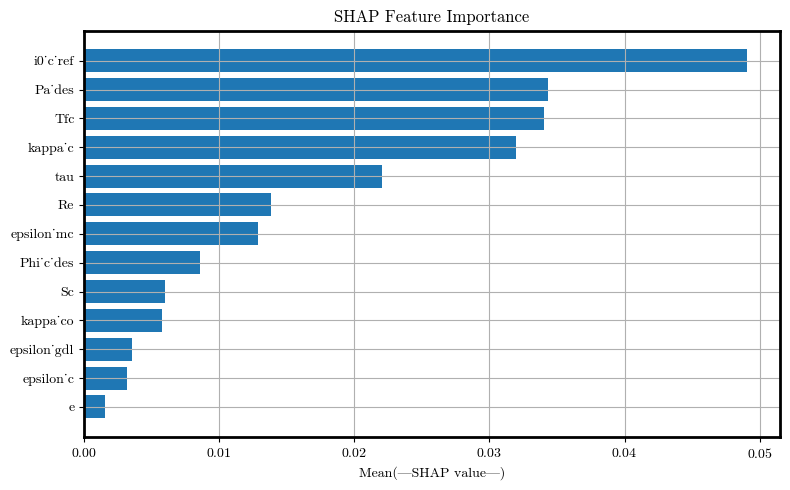

In [20]:
plot_shap_bar(shap_df_ohmic)

### Step 3: Sobol Analysis on Surrogate

To estimate global sensitivities, we run first-order Sobol analysis on the trained surrogate model (`model_ohmic`). This allows us to approximate the impact of each input parameter on the predicted AUC in the ohmic region, without running expensive AlphaPEM simulations.

We vary the sample size `N` to study the stability of the index estimates. For each setting, we:

1. Generate Saltelli samples
2. Predict AUC using the surrogate
3. Compute Sobol first-order indices using SALib
4. Check whether the indices sum to ~1, which indicates consistency

In [ ]:
N_list = [256, 512, 1024, 2048, 4096, 8192]  

# Run the analysis
all_sobol_results_ohmic = run_sobol_analysis(
    model=model_ohmic,
    param_ranges=PARAMETER_RANGES,
    input_cols=INPUT_COLUMNS,
    N_list=N_list,
    calc_second_order=True,
    verbose=True
)


[INFO] Sobol analysis with N=256 (second-order: True)
[INFO] Sum S1 = 1.0118
[INFO] Sum S2 (unique pairs) = -0.1690
[INFO] Sum S1 + S2 = 0.8428 (should be ≈ 1)
[INFO] Sum ST = 1.1578 (may be > 1 due to overlaps)
[WARNING] S1 + S2 does not sum to 1 — surrogate may be biased or incomplete.

[INFO] Sobol analysis with N=512 (second-order: True)
[INFO] Sum S1 = 0.9375
[INFO] Sum S2 (unique pairs) = -0.3888
[INFO] Sum S1 + S2 = 0.5487 (should be ≈ 1)
[INFO] Sum ST = 1.1432 (may be > 1 due to overlaps)
[WARNING] S1 + S2 does not sum to 1 — surrogate may be biased or incomplete.

[INFO] Sobol analysis with N=1024 (second-order: True)
[INFO] Sum S1 = 0.8470
[INFO] Sum S2 (unique pairs) = 0.1785
[INFO] Sum S1 + S2 = 1.0255 (should be ≈ 1)
[INFO] Sum ST = 1.1548 (may be > 1 due to overlaps)

[INFO] Sobol analysis with N=2048 (second-order: True)
[INFO] Sum S1 = 0.8905
[INFO] Sum S2 (unique pairs) = 0.2099
[INFO] Sum S1 + S2 = 1.1004 (should be ≈ 1)
[INFO] Sum ST = 1.1530 (may be > 1 due to over

In [20]:
sobol_results_ohmic = {
    N: res["sobol_df"] for N, res in all_sobol_results_ohmic.items()
}

In [22]:
N_list = [256, 512, 1024, 2048, 4096, 8192]  

In [ ]:
N_best = N_list[-1] 

# Extract components for N_best
sobol_df_ohmic = all_sobol_results_ohmic[N_best]["sobol_df"]
Si_ohmic = all_sobol_results_ohmic[N_best]["Si"]
s1_sum_ohmic = all_sobol_results_ohmic[N_best]["s1_sum"]
s2_sum_ohmic = all_sobol_results_ohmic[N_best]["s2_sum"]
st_sum_ohmic = all_sobol_results_ohmic[N_best]["st_sum"]

total_Si_ohmic, first_Si_ohmic, second_Si_ohmic = Si_ohmic.to_df()

In [82]:
for N, df in sobol_results_ohmic.items():
    print(f"\n--- Sobol Results (N = {N}) ---")
    print(df.head(13))


--- Sobol Results (N = 256) ---
        feature        S1            S1_CI        ST           ST_CI  \
0      i0_c_ref  0.370629     (0.241, 0.5)  0.442531   (0.35, 0.535)   
1        Pa_des  0.083466    (0.01, 0.157)  0.207450  (0.156, 0.258)   
2           Tfc  0.132348   (0.057, 0.207)  0.152630   (0.115, 0.19)   
3       kappa_c  0.137879   (0.073, 0.202)  0.132286  (0.098, 0.166)   
4           tau  0.061291   (0.004, 0.118)  0.103594  (0.078, 0.129)   
5    epsilon_mc  0.035503    (0.001, 0.07)  0.034050  (0.024, 0.044)   
6            Re  0.000591  (-0.032, 0.033)  0.032479  (0.022, 0.043)   
7     Phi_c_des -0.003232  (-0.028, 0.022)  0.021890  (0.015, 0.029)   
8            Sc  0.001120   (-0.03, 0.032)  0.016913  (0.011, 0.023)   
9      kappa_co  0.001876   (-0.017, 0.02)  0.009461  (0.007, 0.012)   
10    epsilon_c -0.008681  (-0.026, 0.009)  0.006608  (0.004, 0.009)   
11  epsilon_gdl  0.011720  (-0.004, 0.027)  0.005892  (0.004, 0.008)   
12            e -0.000515  (-0.

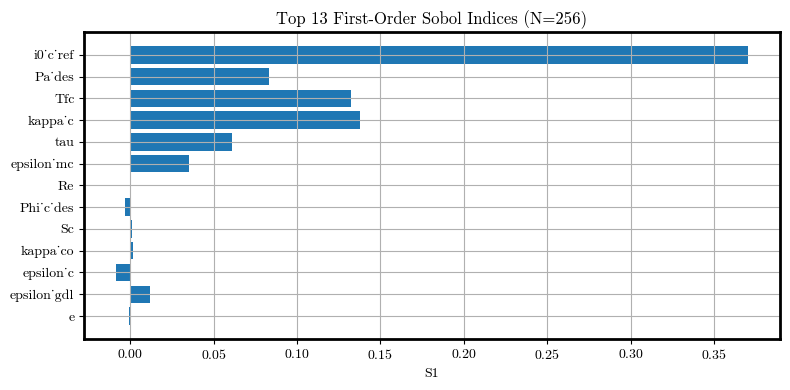

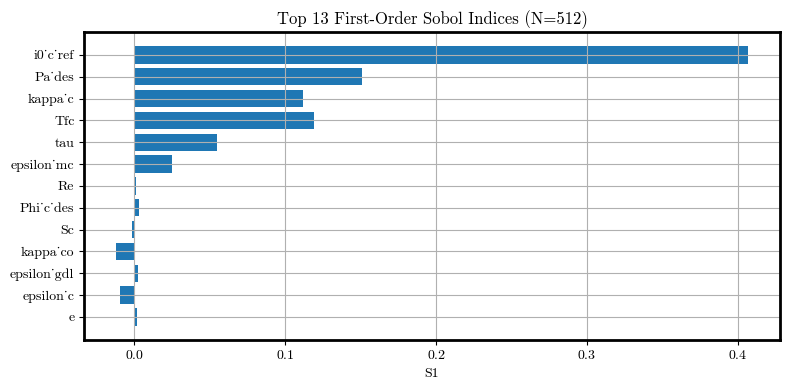

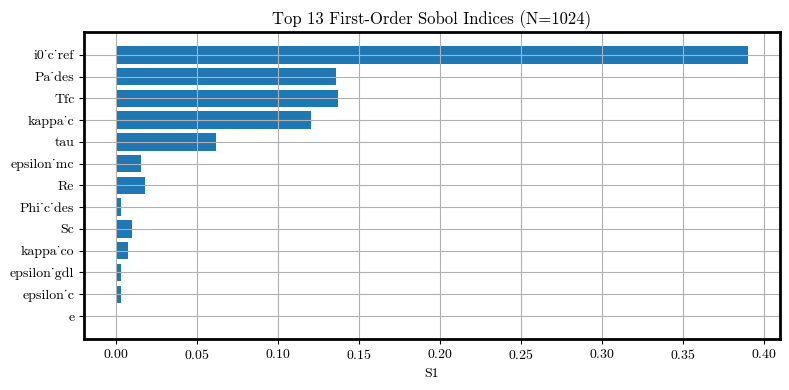

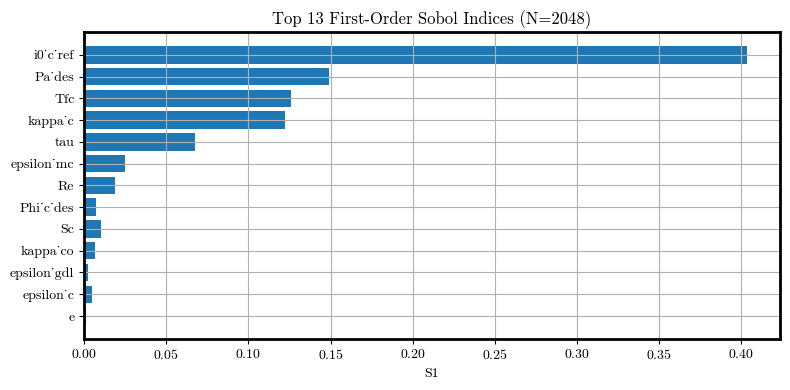

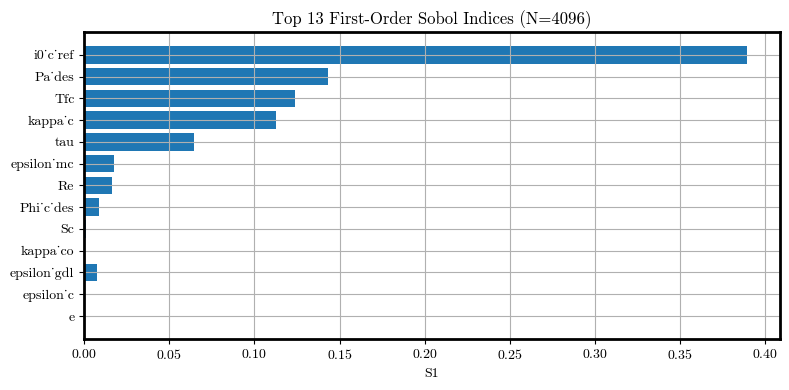

In [83]:
plot_sobol_ranking(sobol_results_ohmic, top_n = 13)

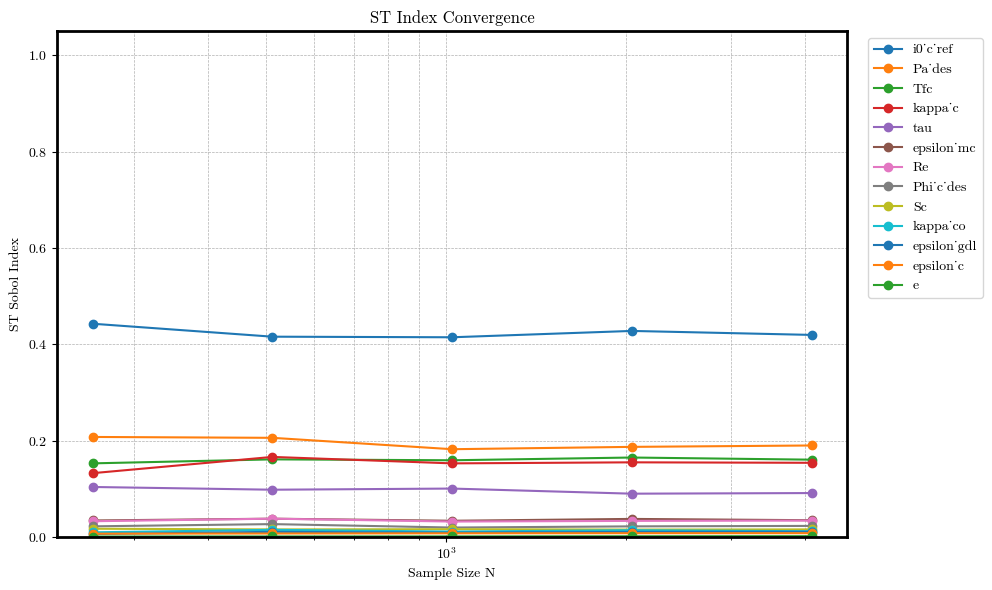

In [84]:
plot_sobol_index_convergence(sobol_results_ohmic, top_k=13, index_type="ST")

C:\Users\User\AppData\Local\Temp\ipykernel_9652\1481252223.py:41: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab10" if top_k <= 10 else "tab20", top_k)


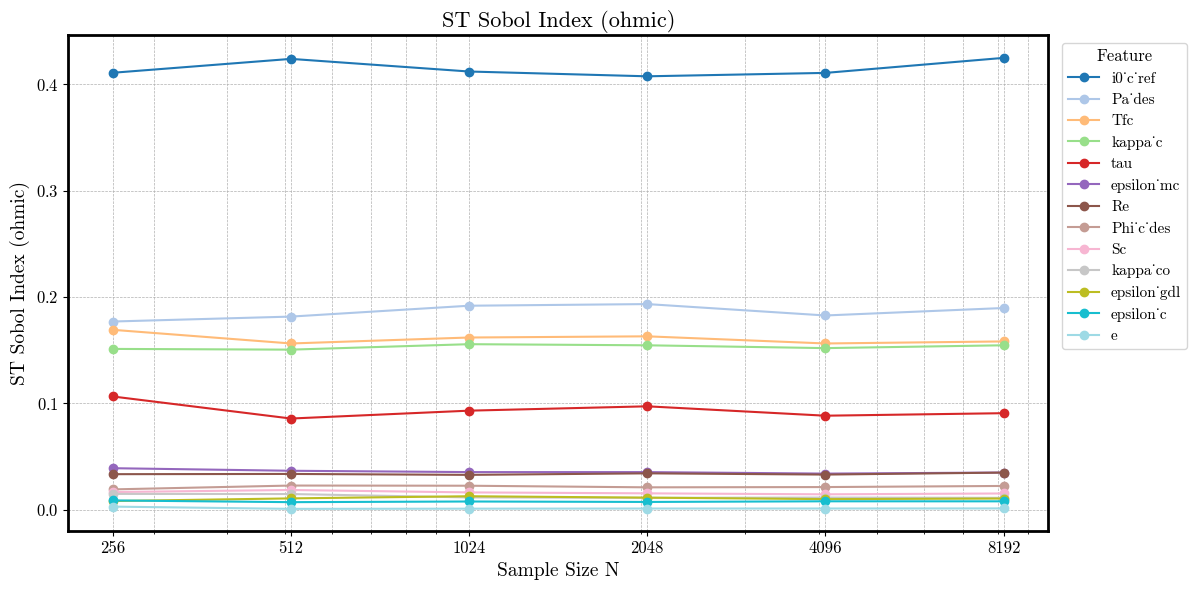

In [98]:
plot_sobol_index_convergence(sobol_results_ohmic, top_k=13, index_type="ST", region = "ohmic")

In [99]:
extract_confidence_halfwidths(all_sobol_results_ohmic[8192]["sobol_df"], decimals=2)

,feature,S1,S1_conf,S1_CI,ST,ST_conf,ST_CI,S2_conf,S2_CI,S2_total
0,i0_c_ref,0.39,0.02,"(0.37, 0.409)",0.42,0.01,"(0.41, 0.439)",0.07,"(-0.055, 0.08)",0.01
1,Pa_des,0.15,0.01,"(0.135, 0.162)",0.19,0.01,"(0.181, 0.198)",0.21,"(-0.178, 0.246)",0.03
2,Tfc,0.13,0.01,"(0.121, 0.143)",0.16,0.01,"(0.151, 0.165)",0.21,"(-0.156, 0.258)",0.05
3,kappa_c,0.12,0.01,"(0.107, 0.131)",0.15,0.01,"(0.148, 0.161)",0.00,"(0.0, 0.0)",0.00
4,tau,0.07,0.01,"(0.059, 0.077)",0.09,0.00,"(0.087, 0.095)",0.10,"(-0.113, 0.079)",-0.02
5,epsilon_mc,0.02,0.01,"(0.013, 0.024)",0.04,0.00,"(0.033, 0.037)",0.05,"(-0.043, 0.058)",0.01
6,Re,0.03,0.00,"(0.021, 0.031)",0.03,0.00,"(0.033, 0.037)",0.02,"(-0.039, 0.007)",-0.02
7,Phi_c_des,0.01,0.00,"(0.006, 0.015)",0.02,0.00,"(0.021, 0.024)",0.07,"(-0.078, 0.055)",-0.01
8,Sc,0.00,0.00,"(-0.0, 0.007)",0.02,0.00,"(0.014, 0.016)",0.05,"(-0.021, 0.084)",0.03
9,kappa_co,0.00,0.00,"(-0.0, 0.006)",0.01,0.00,"(0.01, 0.012)",0.00,"(-0.003, 0.007)",0.00


### Step 4: Save the results

In [103]:
save_model_results(
    model=model_ohmic,
    region_name="ohmic",
    input_cols=INPUT_COLUMNS,
    df=valid_data,
    cv_scores=metrics_ohmic,
    shap_df=shap_df_ohmic,
    all_sobol_results=all_sobol_results_ohmic,
    tag="cropping_full"
)

[INFO] Saved model to ../results/xgboost\xgb_ohmic_cropping_full_model.pkl
[INFO] Saved metrics to ../results/xgboost\xgb_ohmic_cropping_full_metrics.json
[INFO] Saved SHAP ranking to ../results/xgboost\xgb_ohmic_cropping_full_shap.csv
[INFO] Saved all Sobol results to ../results/xgboost\xgb_ohmic_cropping_full_all_sobol.pkl


## Processing: Activation region

This region covers low current densities (ifc < 0.4). Let's train the surrogate and evaluate everything.

### Step 1: Train the Surrogate Model

In [41]:
model_activation, metrics_activation = train_auc_model_for_region(
    valid_data, region_name="activation", input_cols=INPUT_COLUMNS, cv_scoring="r2"
)

print("Metrics for the Activation region")
print(metrics_activation)

[INFO] Starting nested CV for region: 'activation' in range (0.0, 0.4)
[INFO] CV inner scoring: r2
[INFO] Identified 31 current density columns and 31 voltage columns.
[INFO] Computing AUC target for region: activation
[INFO] Dropped 0 samples with no valid AUC in this region. Remaining: 54984
[INFO] Input shape: (54984, 13). Target shape: (54984,)
[INFO] Defined hyperparameter grid with 72 combinations

[INFO] Starting outer fold 1/5
[INFO] Performing inner grid search (3-fold CV)...
[INFO] Best hyperparameters for fold 1: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 700, 'subsample': 0.8}
[INFO] Fold 1 results — MAE=0.0043, R²=0.8453, RMSE=0.0001

[INFO] Starting outer fold 2/5
[INFO] Performing inner grid search (3-fold CV)...
[INFO] Best hyperparameters for fold 2: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 700, 'subsample': 0.8}
[INFO] Fold 2 results — MAE=0.0043, R²=0.8379, RMSE=0.0002

[INFO] Starting oute

### Step 2: Shapley values

In [42]:
# SHAP analysis on full data
shap_df_activation = compute_shap_importance(
    model=model_activation,
    df=valid_data,
    region_name="activation",
    input_cols=INPUT_COLUMNS,
    sample_frac=1
)

shap_df_activation

[INFO] Using full dataset (54984 rows) for SHAP.
[INFO] Creating SHAP TreeExplainer...
[INFO] Computing SHAP values...
[INFO] Aggregating mean absolute SHAP values per feature...


,feature,mean_abs_shap
10,i0_c_ref,0.013248
12,kappa_c,0.009995
0,Tfc,0.006523
1,Pa_des,0.004462
11,kappa_co,0.003169
5,tau,0.002977
2,Sc,0.001965
6,epsilon_mc,0.001735
9,Re,0.001006
3,Phi_c_des,0.000636


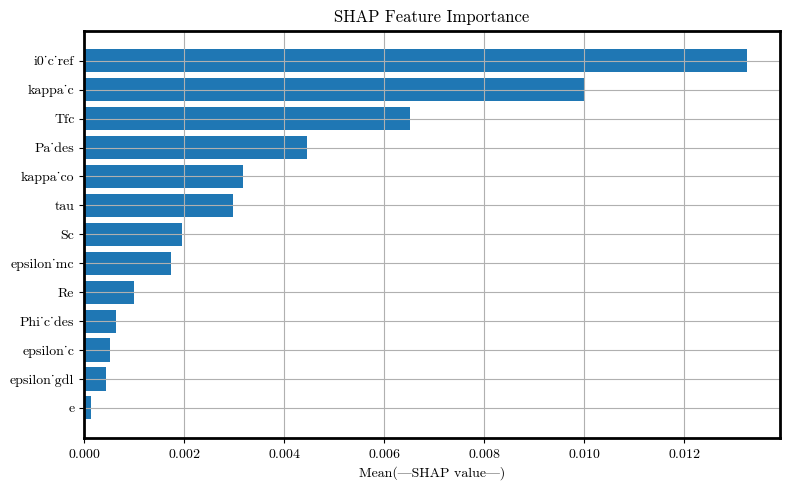

In [43]:
plot_shap_bar(shap_df_activation)

### Step 3: Sobol SA

In [94]:
N_list = [256, 512, 1024, 2048, 4096, 8192]  

# Run the analysis
all_sobol_results_activation = run_sobol_analysis(
    model=model_activation,
    param_ranges=PARAMETER_RANGES,
    input_cols=INPUT_COLUMNS,
    N_list=N_list,
    calc_second_order=True,
    verbose=True
)

sobol_results_activation = {
    N: res["sobol_df"] for N, res in all_sobol_results_activation.items()
}


[INFO] Sobol analysis with N=256 (second-order: True)
[INFO] Sum S1 = 0.9766
[INFO] Sum S2 (unique pairs) = 0.3113
[INFO] Sum S1 + S2 = 1.2879 (should be ≈ 1)
[INFO] Sum ST = 1.0741 (may be > 1 due to overlaps)
[WARNING] S1 + S2 does not sum to 1 — surrogate may be biased or incomplete.

[INFO] Sobol analysis with N=512 (second-order: True)
[INFO] Sum S1 = 0.9903
[INFO] Sum S2 (unique pairs) = -0.2294
[INFO] Sum S1 + S2 = 0.7609 (should be ≈ 1)
[INFO] Sum ST = 1.0465 (may be > 1 due to overlaps)
[WARNING] S1 + S2 does not sum to 1 — surrogate may be biased or incomplete.

[INFO] Sobol analysis with N=1024 (second-order: True)
[INFO] Sum S1 = 0.9418
[INFO] Sum S2 (unique pairs) = 0.3845
[INFO] Sum S1 + S2 = 1.3263 (should be ≈ 1)
[INFO] Sum ST = 1.0917 (may be > 1 due to overlaps)
[WARNING] S1 + S2 does not sum to 1 — surrogate may be biased or incomplete.

[INFO] Sobol analysis with N=2048 (second-order: True)
[INFO] Sum S1 = 0.9495
[INFO] Sum S2 (unique pairs) = 0.3110
[INFO] Sum S1 

In [95]:
# Print Sobol outputs
for N, df in sobol_results_activation.items():
    print(f"\n--- Sobol Results (Activation, N = {N}) ---")
    print(df.head(13))


--- Sobol Results (Activation, N = 256) ---
        feature        S1            S1_CI        ST           ST_CI  \
0      i0_c_ref  0.519641   (0.374, 0.665)  0.537398  (0.441, 0.633)   
1       kappa_c  0.263775   (0.163, 0.365)  0.257193    (0.2, 0.314)   
2           Tfc  0.104966   (0.054, 0.156)  0.096400  (0.075, 0.118)   
3        Pa_des  0.046993  (-0.001, 0.095)  0.068837  (0.048, 0.089)   
4           tau  0.014218  (-0.014, 0.042)  0.033374  (0.023, 0.044)   
5      kappa_co  0.014229  (-0.013, 0.041)  0.024449  (0.018, 0.031)   
6    epsilon_mc  0.006533  (-0.015, 0.028)  0.019749  (0.006, 0.033)   
7            Sc  0.013235  (-0.005, 0.032)  0.014503   (0.009, 0.02)   
8            Re -0.003399   (-0.016, 0.01)  0.008309  (0.005, 0.012)   
9     Phi_c_des -0.006243   (-0.02, 0.007)  0.005659  (0.003, 0.008)   
10  epsilon_gdl -0.000530   (-0.01, 0.009)  0.004182  (0.001, 0.007)   
11    epsilon_c  0.003837  (-0.008, 0.016)  0.003798  (0.002, 0.005)   
12            e -0.

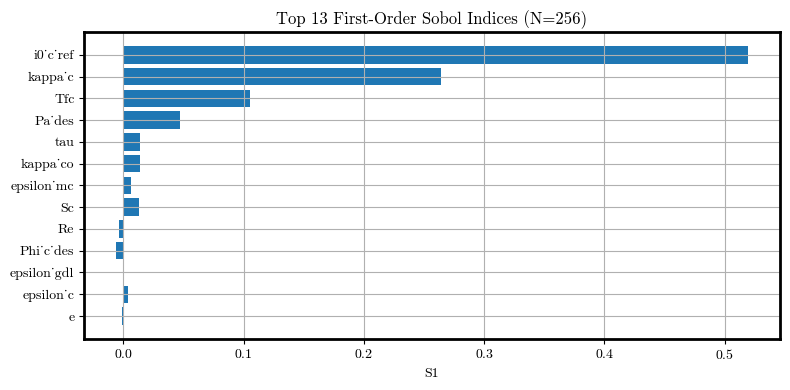

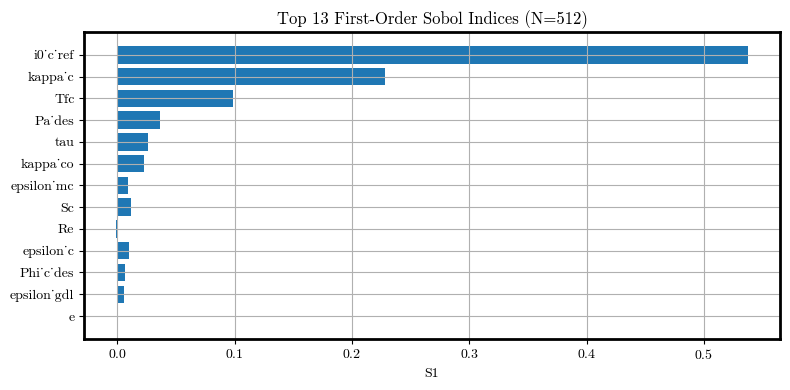

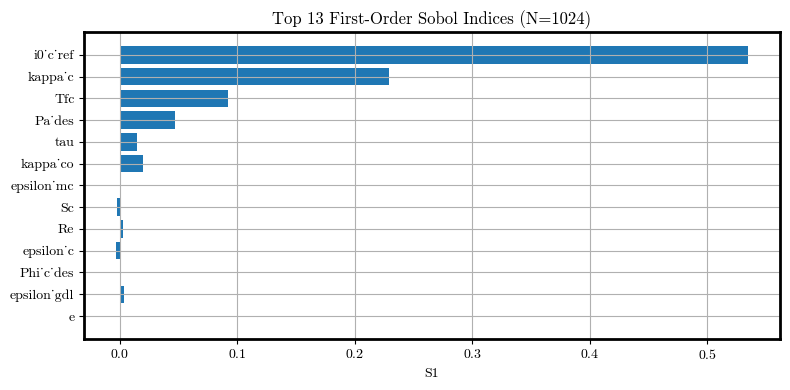

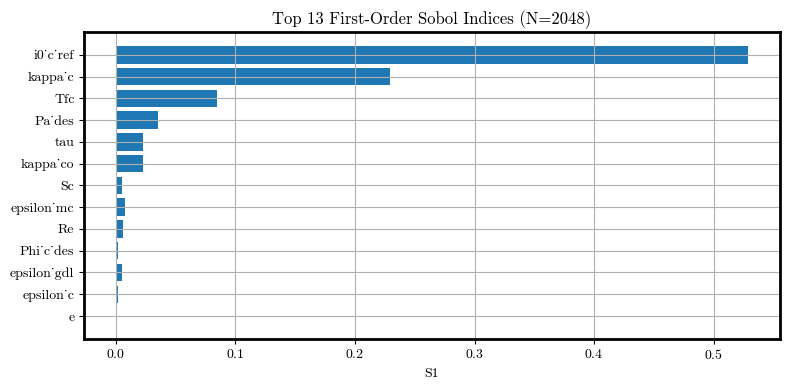

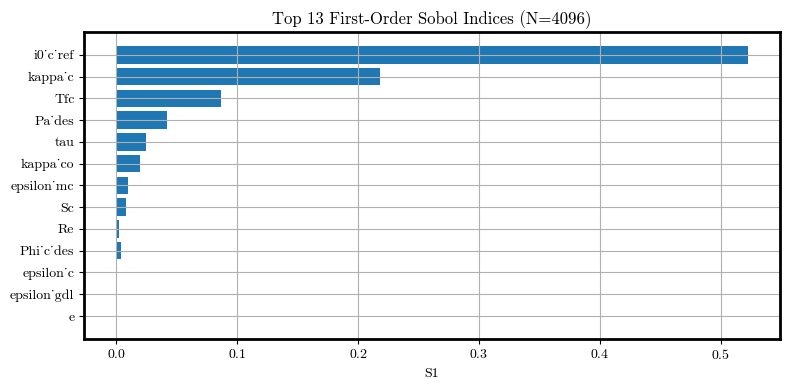

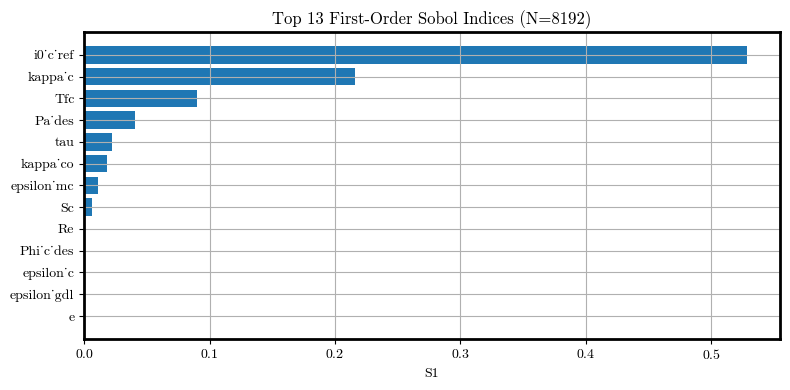

In [97]:
# Show and save Sobol + SHAP results
plot_sobol_ranking(sobol_results_activation, top_n=13)

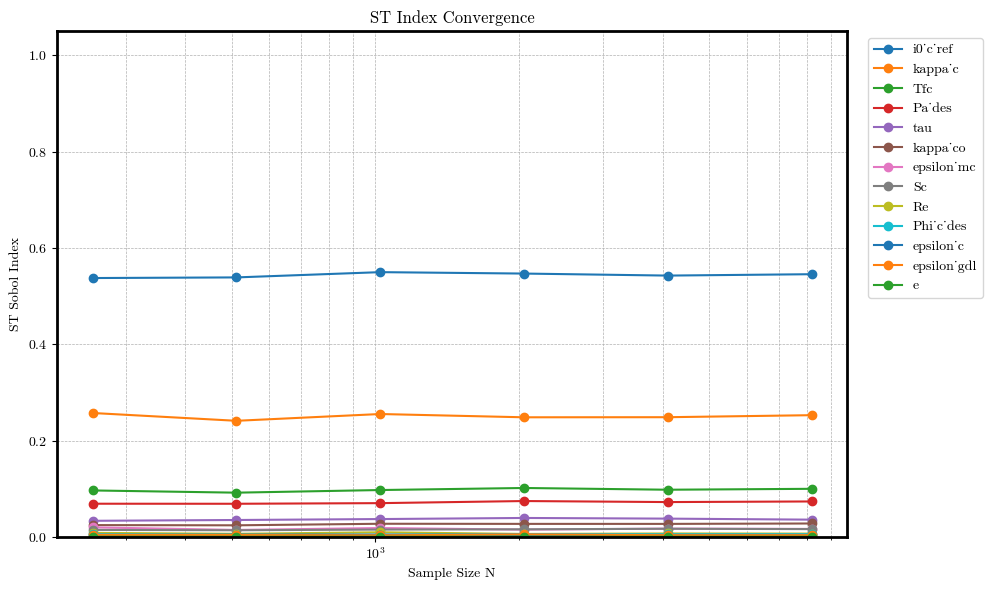

In [98]:
plot_sobol_index_convergence(sobol_results_activation, top_k=13, index_type="ST")

#### Delete from here

In [63]:
sobol_results_activation[8192]

,feature,S1,S1_CI,ST,ST_CI,S2_total,S2_CI
0,i0_c_ref,0.528442,"(0.5, 0.556)",0.545352,"(0.524, 0.567)",0.012589,"(-0.075, 0.1)"
1,kappa_c,0.216143,"(0.202, 0.231)",0.252659,"(0.241, 0.264)",0.000000,"(0.0, 0.0)"
2,Tfc,0.089897,"(0.08, 0.099)",0.099784,"(0.096, 0.104)",0.003825,"(-0.167, 0.175)"
3,Pa_des,0.040966,"(0.032, 0.05)",0.073528,"(0.07, 0.077)",0.053414,"(-0.094, 0.201)"
4,tau,0.022590,"(0.017, 0.028)",0.035759,"(0.033, 0.038)",0.004482,"(-0.055, 0.064)"
5,kappa_co,0.018340,"(0.014, 0.023)",0.027783,"(0.027, 0.029)",0.002077,"(-0.005, 0.009)"
6,epsilon_mc,0.011303,"(0.007, 0.015)",0.016520,"(0.015, 0.018)",-0.013645,"(-0.053, 0.026)"
7,Sc,0.006458,"(0.002, 0.01)",0.016125,"(0.015, 0.017)",0.024725,"(-0.035, 0.084)"
8,Re,0.000133,"(-0.002, 0.003)",0.006807,"(0.006, 0.008)",0.005221,"(-0.005, 0.015)"
9,Phi_c_des,0.000946,"(-0.001, 0.003)",0.005566,"(0.005, 0.006)",0.022037,"(-0.006, 0.05)"


In [77]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

def plot_sobol_index_convergence(sobol_results, index_type="ST", top_k=8, title=None, log_x=True, region = None):
    """
    Plot how each feature's Sobol index (S1 or ST) changes as sample size N increases.

    Parameters
    ----------
    sobol_results : dict
        Output from run_sobol_analysis(). Maps N → DataFrame with columns ['feature', ..., 'S1', 'ST'].
    index_type : str
        Which index to plot: "S1" for first-order or "ST" for total-order.
    top_k : int
        Number of top features to show based on the highest N.
    title : str or None
        Custom plot title. If None, defaults to f"{index_type} Index Convergence".
    log_x : bool
        Use log scale on the x-axis (sample size N).
    """
    assert index_type in ["S1", "ST"], "index_type must be 'S1' or 'ST'"

    max_N = max(sobol_results)
    top_features = (
        sobol_results[max_N]
        .sort_values(index_type, ascending=False)["feature"]
        .head(top_k)
        .tolist()
    )

    N_vals = sorted(sobol_results.keys())
    data = {f: [] for f in top_features}
    for N in N_vals:
        df = sobol_results[N].set_index("feature")
        for f in top_features:
            v = df.loc[f, index_type] if f in df.index else np.nan
            data[f].append(v)

    # Set up distinct colors
    cmap = cm.get_cmap("tab10" if top_k <= 10 else "tab20", top_k)
    colors = [cmap(i) for i in range(top_k)]

    # Plot
    plt.figure(figsize=(12, 6))
    for i, f in enumerate(top_features):
        plt.plot(N_vals, data[f], marker="o", label=f, color=colors[i])

    title = f"{index_type} Sobol Index"
    if region != None:
        title = title + " (" + region + ")"
    plt.ylabel(title, fontsize=14)
    plt.xlabel("Sample Size N", fontsize=14)
    #plt.ylim(0, 1.05)
    if title is None:
        title = f"{index_type} Index Convergence"
    plt.title(title, fontsize=16)

    if log_x:
        plt.xscale("log")
        plt.xticks(N_vals, [str(n) for n in N_vals], fontsize=12)
    else:
        plt.xticks(fontsize=12)

    plt.yticks(fontsize=12)
    plt.grid(True, which="both", linestyle="--", linewidth=0.5)
    plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1.0), fontsize=11, title="Feature", title_fontsize=12)
    plt.tight_layout()
    plt.show()


C:\Users\User\AppData\Local\Temp\ipykernel_9652\1481252223.py:41: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab10" if top_k <= 10 else "tab20", top_k)


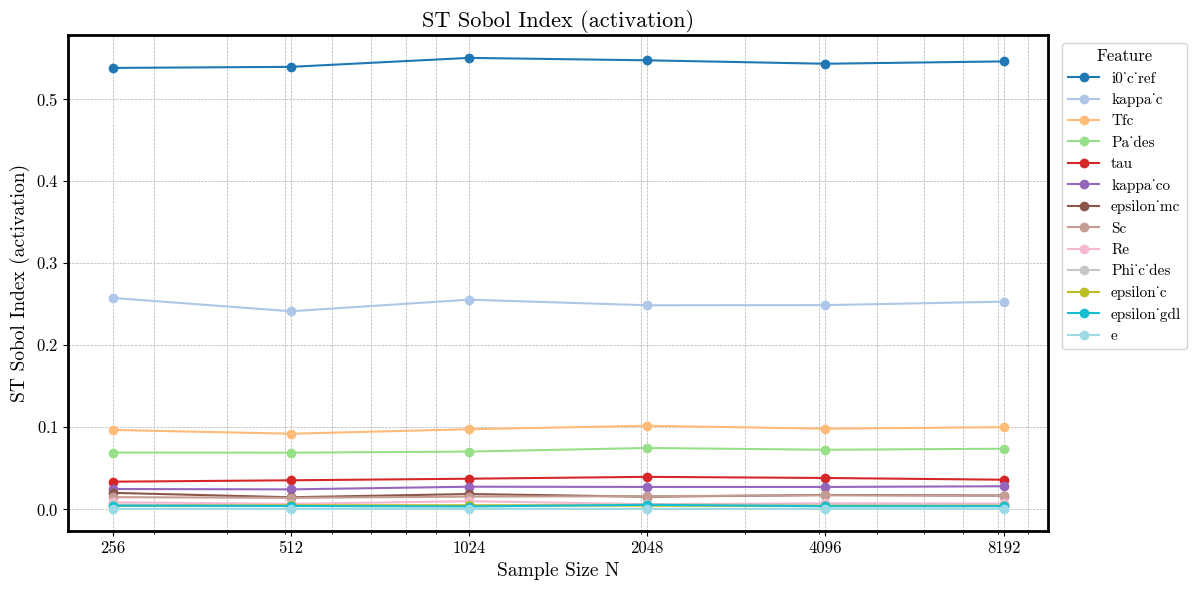

In [78]:
plot_sobol_index_convergence(sobol_results_activation, top_k=13, index_type="ST", region = "activation")

In [88]:
all_sobol_results_activation[8192]["sobol_df"]

,feature,S1,S1_CI,ST,ST_CI,S2_total,S2_CI
0,i0_c_ref,0.528442,"(0.5, 0.556)",0.545352,"(0.524, 0.567)",0.012589,"(-0.075, 0.1)"
1,kappa_c,0.216143,"(0.202, 0.231)",0.252659,"(0.241, 0.264)",0.000000,"(0.0, 0.0)"
2,Tfc,0.089897,"(0.08, 0.099)",0.099784,"(0.096, 0.104)",0.003825,"(-0.167, 0.175)"
3,Pa_des,0.040966,"(0.032, 0.05)",0.073528,"(0.07, 0.077)",0.053414,"(-0.094, 0.201)"
4,tau,0.022590,"(0.017, 0.028)",0.035759,"(0.033, 0.038)",0.004482,"(-0.055, 0.064)"
5,kappa_co,0.018340,"(0.014, 0.023)",0.027783,"(0.027, 0.029)",0.002077,"(-0.005, 0.009)"
6,epsilon_mc,0.011303,"(0.007, 0.015)",0.016520,"(0.015, 0.018)",-0.013645,"(-0.053, 0.026)"
7,Sc,0.006458,"(0.002, 0.01)",0.016125,"(0.015, 0.017)",0.024725,"(-0.035, 0.084)"
8,Re,0.000133,"(-0.002, 0.003)",0.006807,"(0.006, 0.008)",0.005221,"(-0.005, 0.015)"
9,Phi_c_des,0.000946,"(-0.001, 0.003)",0.005566,"(0.005, 0.006)",0.022037,"(-0.006, 0.05)"


In [93]:
def extract_confidence_halfwidths(df, decimals=2):
    """
    Given a Sobol results DataFrame with _CI columns (as tuples),
    compute half-widths of the confidence intervals, add _conf columns,
    and return a reordered, rounded DataFrame.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with columns like 'S1', 'S1_CI', 'ST', 'ST_CI', 'S2_total', 'S2_CI'.
    decimals : int
        Number of decimal places to round all numeric values (default is 2).

    Returns
    -------
    pd.DataFrame
        DataFrame with added _conf columns and reordered columns:
        'S1', 'S1_conf', 'S1_CI', ..., all rounded to given decimal places.
    """
    df = df.copy()

    # Compute _conf columns
    for base in ["S1", "ST", "S2"]:
        ci_col = f"{base}_CI"
        if ci_col in df.columns:
            conf_col = f"{base}_conf"
            df[conf_col] = df[ci_col].apply(lambda ci: round((ci[1] - ci[0]) / 2, decimals) if isinstance(ci, (tuple, list)) else np.nan)

    # Round numeric columns
    for col in df.select_dtypes(include=[float, int]).columns:
        df[col] = df[col].round(decimals)

    # Desired column order
    new_order = ["feature"]
    for base in ["S1", "ST", "S2"]:
        if base in df.columns:
            new_order.append(base)
        if f"{base}_conf" in df.columns:
            new_order.append(f"{base}_conf")
        if f"{base}_CI" in df.columns:
            new_order.append(f"{base}_CI")

    # Add any remaining columns
    other_cols = [col for col in df.columns if col not in new_order]
    return df[new_order + other_cols]


In [96]:
extract_confidence_halfwidths(all_sobol_results_activation[8192]["sobol_df"], decimals=2)

,feature,S1,S1_conf,S1_CI,ST,ST_conf,ST_CI,S2_conf,S2_CI,S2_total
0,i0_c_ref,0.53,0.03,"(0.5, 0.556)",0.55,0.02,"(0.524, 0.567)",0.09,"(-0.075, 0.1)",0.01
1,kappa_c,0.22,0.01,"(0.202, 0.231)",0.25,0.01,"(0.241, 0.264)",0.00,"(0.0, 0.0)",0.00
2,Tfc,0.09,0.01,"(0.08, 0.099)",0.10,0.00,"(0.096, 0.104)",0.17,"(-0.167, 0.175)",0.00
3,Pa_des,0.04,0.01,"(0.032, 0.05)",0.07,0.00,"(0.07, 0.077)",0.15,"(-0.094, 0.201)",0.05
4,tau,0.02,0.01,"(0.017, 0.028)",0.04,0.00,"(0.033, 0.038)",0.06,"(-0.055, 0.064)",0.00
5,kappa_co,0.02,0.00,"(0.014, 0.023)",0.03,0.00,"(0.027, 0.029)",0.01,"(-0.005, 0.009)",0.00
6,epsilon_mc,0.01,0.00,"(0.007, 0.015)",0.02,0.00,"(0.015, 0.018)",0.04,"(-0.053, 0.026)",-0.01
7,Sc,0.01,0.00,"(0.002, 0.01)",0.02,0.00,"(0.015, 0.017)",0.06,"(-0.035, 0.084)",0.02
8,Re,0.00,0.00,"(-0.002, 0.003)",0.01,0.00,"(0.006, 0.008)",0.01,"(-0.005, 0.015)",0.01
9,Phi_c_des,0.00,0.00,"(-0.001, 0.003)",0.01,0.00,"(0.005, 0.006)",0.03,"(-0.006, 0.05)",0.02


### Step 4: Save the results

In [104]:
save_model_results(
    model=model_activation,
    region_name="activation",
    input_cols=INPUT_COLUMNS,
    df=valid_data,
    cv_scores=metrics_activation,
    shap_df=shap_df_activation,
    all_sobol_results=all_sobol_results_activation,
    tag="cropping_full"
)

[INFO] Saved model to ../results/xgboost\xgb_activation_cropping_full_model.pkl
[INFO] Saved metrics to ../results/xgboost\xgb_activation_cropping_full_metrics.json
[INFO] Saved SHAP ranking to ../results/xgboost\xgb_activation_cropping_full_shap.csv
[INFO] Saved all Sobol results to ../results/xgboost\xgb_activation_cropping_full_all_sobol.pkl


## Processing: Mass Transport region
This covers the high current density regime (ifc ≥ 1.6). Let's repeat everything for this region too.

### Step 1: Train the Surrogate Model

In [105]:
model_mass, metrics_mass = train_auc_model_for_region(
    valid_data, region_name="mass_transport", input_cols=INPUT_COLUMNS, cv_scoring="r2"
)

print("Metrics for the Mass Transport region")
print(metrics_mass)

[INFO] Starting nested CV for region: 'mass_transport' in range (1.6, inf)
[INFO] CV inner scoring: r2
[INFO] Identified 31 current density columns and 31 voltage columns.
[INFO] Computing AUC target for region: mass_transport
[INFO] Dropped 1396 samples with no valid AUC in this region. Remaining: 53588
[INFO] Input shape: (53588, 13). Target shape: (53588,)
[INFO] Defined hyperparameter grid with 72 combinations

[INFO] Starting outer fold 1/5
[INFO] Performing inner grid search (3-fold CV)...
[INFO] Best hyperparameters for fold 1: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 700, 'subsample': 0.8}
[INFO] Fold 1 results — MAE=0.0281, R²=0.8245, RMSE=0.0058

[INFO] Starting outer fold 2/5
[INFO] Performing inner grid search (3-fold CV)...
[INFO] Best hyperparameters for fold 2: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 700, 'subsample': 0.8}
[INFO] Fold 2 results — MAE=0.0275, R²=0.8396, RMSE=0.0053

[INFO] St

### Step 2: Shapley values

In [107]:
# SHAP values on full data
shap_df_mass = compute_shap_importance(
    model=model_mass,
    df=valid_data,
    region_name="mass_transport",
    input_cols=INPUT_COLUMNS,
    sample_frac=1
)

shap_df_mass

[INFO] Using full dataset (53588 rows) for SHAP.
[INFO] Creating SHAP TreeExplainer...
[INFO] Computing SHAP values...
[INFO] Aggregating mean absolute SHAP values per feature...


,feature,mean_abs_shap
10,i0_c_ref,0.059776
1,Pa_des,0.052273
0,Tfc,0.047854
9,Re,0.037011
5,tau,0.029920
12,kappa_c,0.026258
6,epsilon_mc,0.022642
3,Phi_c_des,0.012096
2,Sc,0.011342
4,epsilon_gdl,0.006367


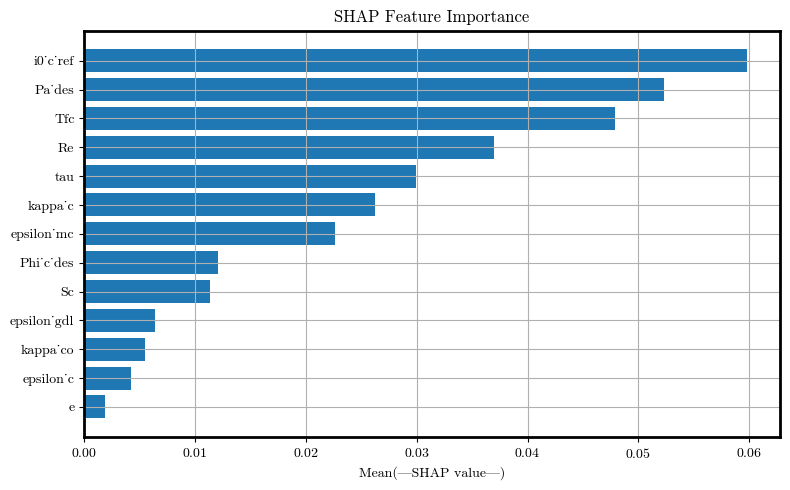

In [108]:
plot_shap_bar(shap_df_mass)

### Step 3: Sobol analysis

In [142]:
N_list = [256, 512, 1024, 2048, 4096, 8192]  

# Run the analysis
all_sobol_results_mass = run_sobol_analysis(
    model=model_mass,
    param_ranges=PARAMETER_RANGES,
    input_cols=INPUT_COLUMNS,
    N_list=N_list,
    calc_second_order=True,
    verbose=True
)

sobol_results_mass = {
    N: res["sobol_df"] for N, res in all_sobol_results_mass.items()
}


[INFO] Sobol analysis with N=256 (second-order: True)
[INFO] Sum S1 = 0.7914
[INFO] Sum S2 (unique pairs) = -0.1591
[INFO] Sum S1 + S2 = 0.6323 (should be ≈ 1)
[INFO] Sum ST = 1.1699 (may be > 1 due to overlaps)
[WARNING] S1 + S2 does not sum to 1 — surrogate may be biased or incomplete.

[INFO] Sobol analysis with N=512 (second-order: True)
[INFO] Sum S1 = 0.9343
[INFO] Sum S2 (unique pairs) = -0.3410
[INFO] Sum S1 + S2 = 0.5933 (should be ≈ 1)
[INFO] Sum ST = 1.1395 (may be > 1 due to overlaps)
[WARNING] S1 + S2 does not sum to 1 — surrogate may be biased or incomplete.

[INFO] Sobol analysis with N=1024 (second-order: True)
[INFO] Sum S1 = 0.9514
[INFO] Sum S2 (unique pairs) = -0.3960
[INFO] Sum S1 + S2 = 0.5554 (should be ≈ 1)
[INFO] Sum ST = 1.1474 (may be > 1 due to overlaps)
[WARNING] S1 + S2 does not sum to 1 — surrogate may be biased or incomplete.

[INFO] Sobol analysis with N=2048 (second-order: True)
[INFO] Sum S1 = 0.8743
[INFO] Sum S2 (unique pairs) = 0.4613
[INFO] Sum S

In [143]:
# Print Sobol tables
for N, df in sobol_results_mass.items():
    print(f"\n--- Sobol Results (Mass Transport, N = {N}) ---")
    print(df.head(13))


--- Sobol Results (Mass Transport, N = 256) ---
        feature        S1            S1_CI        ST           ST_CI  \
0      i0_c_ref  0.257933   (0.148, 0.368)  0.349345   (0.259, 0.44)   
1        Pa_des  0.200454    (0.121, 0.28)  0.252898  (0.191, 0.315)   
2           Tfc  0.166386    (0.08, 0.253)  0.192900  (0.148, 0.238)   
3            Re  0.050664  (-0.004, 0.105)  0.099981  (0.079, 0.121)   
4           tau  0.024248  (-0.027, 0.075)  0.085647  (0.065, 0.106)   
5       kappa_c  0.039384  (-0.007, 0.086)  0.071083  (0.053, 0.089)   
6    epsilon_mc  0.043101    (0.01, 0.077)  0.046844  (0.036, 0.058)   
7     Phi_c_des  0.012669  (-0.013, 0.039)  0.028288  (0.019, 0.038)   
8            Sc  0.004333  (-0.019, 0.028)  0.018379  (0.014, 0.023)   
9   epsilon_gdl -0.008013  (-0.031, 0.015)  0.009955  (0.007, 0.013)   
10    epsilon_c -0.005346   (-0.021, 0.01)  0.007566   (0.005, 0.01)   
11     kappa_co  0.008098  (-0.007, 0.023)  0.006309  (0.004, 0.008)   
12            e

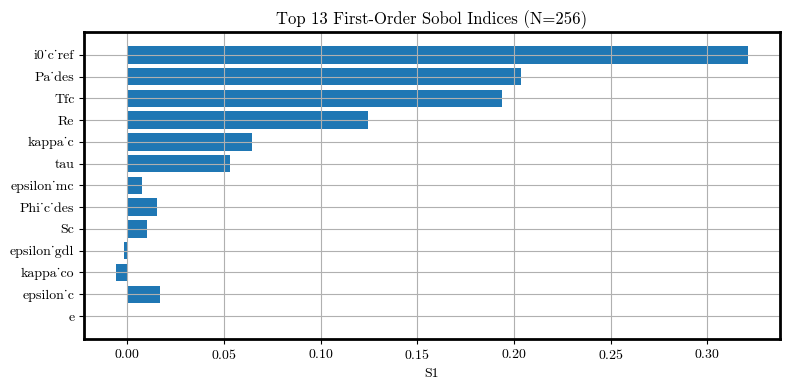

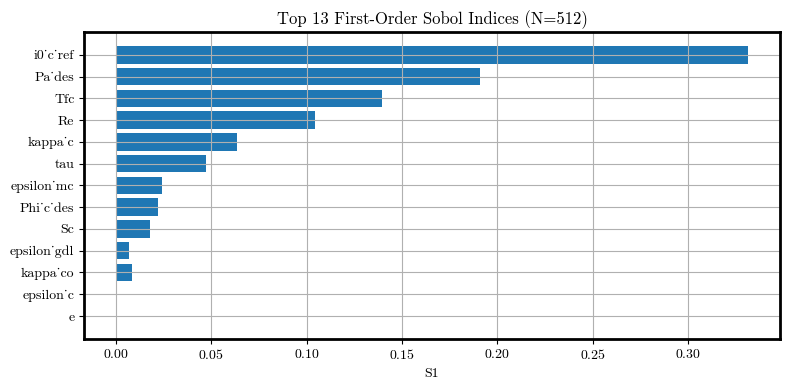

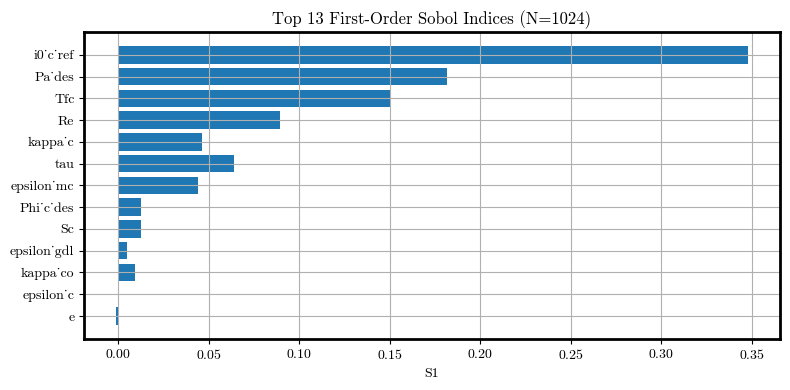

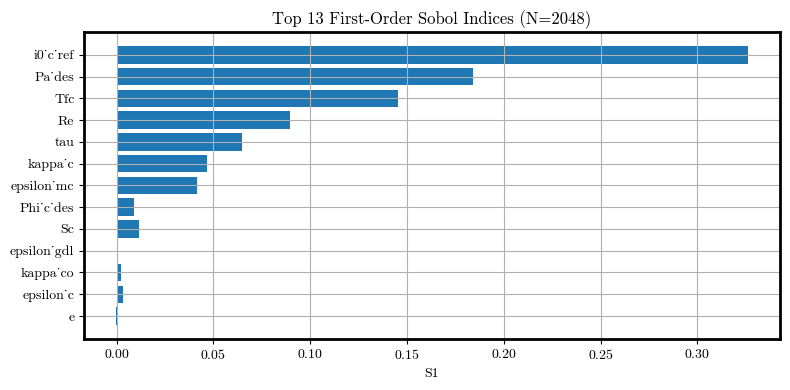

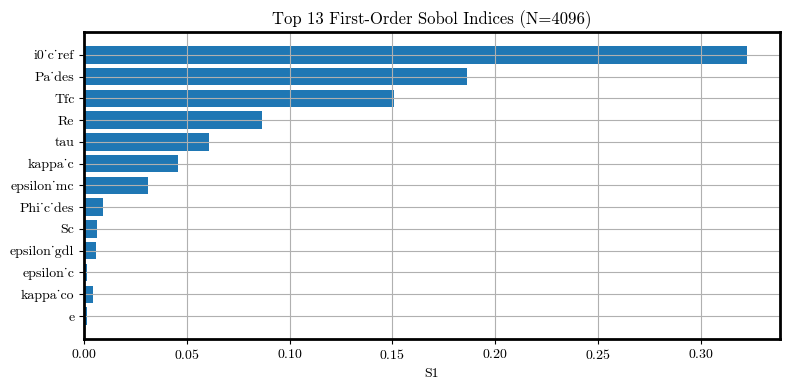

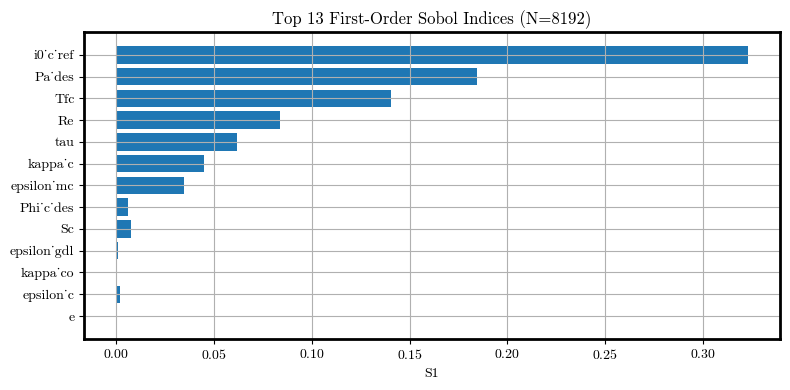

In [111]:
# Show and save visuals
plot_sobol_ranking(sobol_results_mass, top_n=13)

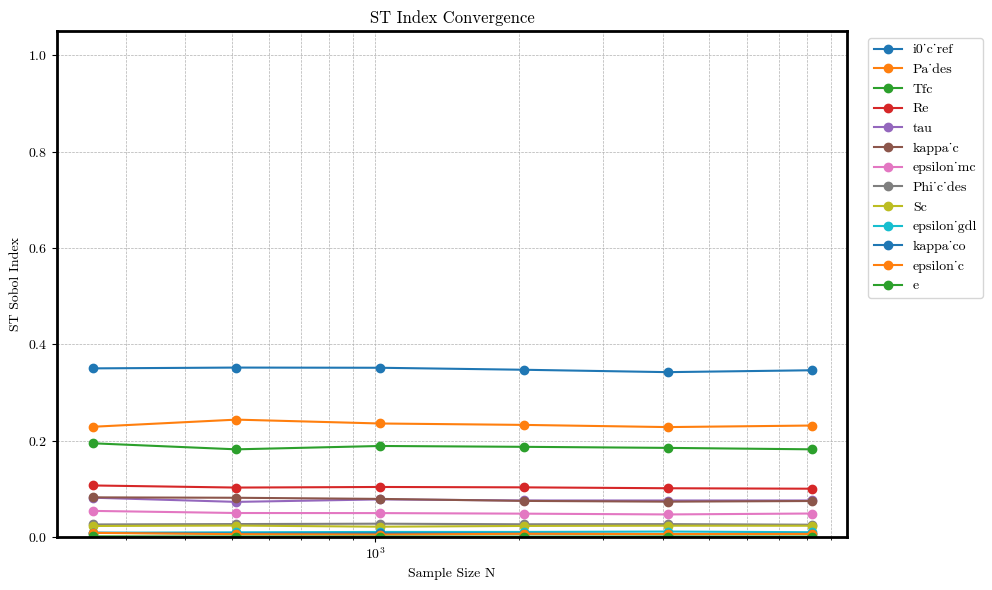

In [112]:
plot_sobol_index_convergence(sobol_results_mass, top_k=13, index_type="ST")

C:\Users\User\AppData\Local\Temp\ipykernel_9652\1481252223.py:41: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab10" if top_k <= 10 else "tab20", top_k)


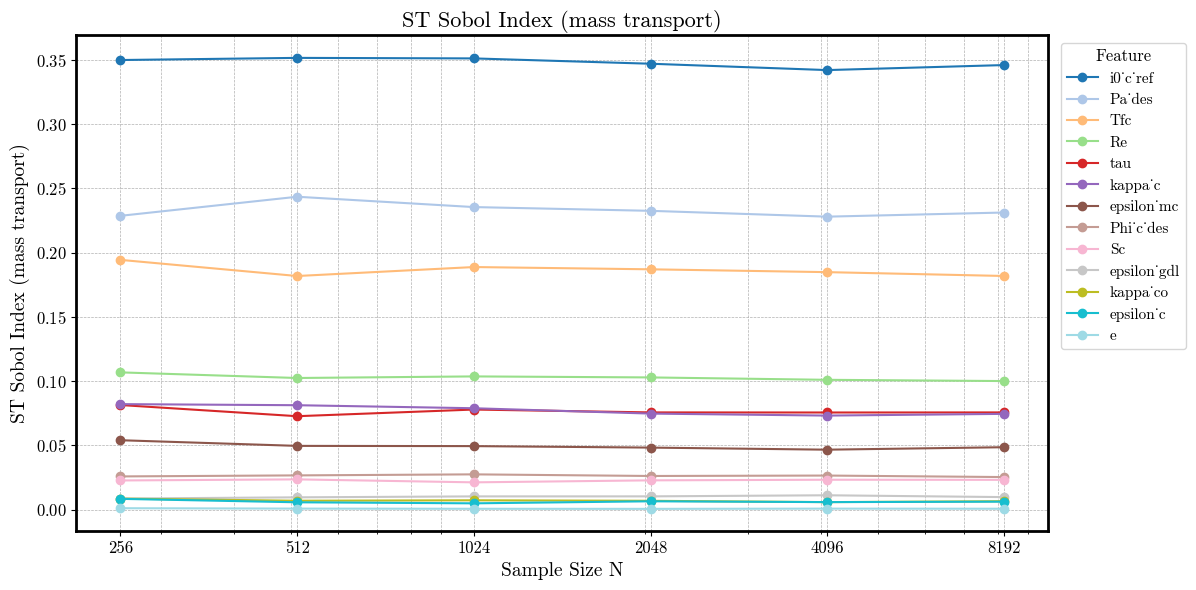

In [100]:
plot_sobol_index_convergence(sobol_results_mass, top_k=13, index_type="ST", region = "mass transport")

In [101]:
extract_confidence_halfwidths(all_sobol_results_mass[8192]["sobol_df"], decimals=2)

,feature,S1,S1_conf,S1_CI,ST,ST_conf,ST_CI,S2_conf,S2_CI,S2_total
0,i0_c_ref,0.32,0.02,"(0.303, 0.344)",0.35,0.01,"(0.332, 0.36)",0.06,"(-0.054, 0.071)",0.01
1,Pa_des,0.18,0.01,"(0.173, 0.196)",0.23,0.01,"(0.222, 0.241)",0.20,"(-0.213, 0.182)",-0.02
2,Tfc,0.14,0.01,"(0.128, 0.153)",0.18,0.01,"(0.175, 0.189)",0.20,"(-0.096, 0.298)",0.10
3,Re,0.08,0.01,"(0.074, 0.094)",0.10,0.00,"(0.096, 0.104)",0.04,"(-0.038, 0.041)",0.00
4,tau,0.06,0.01,"(0.054, 0.07)",0.08,0.00,"(0.072, 0.079)",0.09,"(-0.107, 0.065)",-0.02
5,kappa_c,0.05,0.01,"(0.037, 0.053)",0.07,0.00,"(0.071, 0.078)",0.00,"(0.0, 0.0)",0.00
6,epsilon_mc,0.03,0.01,"(0.027, 0.042)",0.05,0.00,"(0.046, 0.051)",0.06,"(-0.064, 0.058)",-0.00
7,Phi_c_des,0.01,0.00,"(0.001, 0.011)",0.03,0.00,"(0.024, 0.027)",0.07,"(-0.044, 0.095)",0.03
8,Sc,0.01,0.00,"(0.003, 0.013)",0.02,0.00,"(0.021, 0.025)",0.07,"(-0.064, 0.071)",0.00
9,epsilon_gdl,0.00,0.00,"(-0.002, 0.004)",0.01,0.00,"(0.009, 0.01)",0.04,"(-0.03, 0.045)",0.01


### Step 4: Save the results

In [113]:
save_model_results(
    model=model_mass,
    region_name="mass",
    input_cols=INPUT_COLUMNS,
    df=valid_data,
    cv_scores=metrics_mass,
    shap_df=shap_df_mass,
    all_sobol_results=all_sobol_results_mass,
    tag="cropping_full"
)

[INFO] Saved model to ../results/xgboost\xgb_mass_cropping_full_model.pkl
[INFO] Saved metrics to ../results/xgboost\xgb_mass_cropping_full_metrics.json
[INFO] Saved SHAP ranking to ../results/xgboost\xgb_mass_cropping_full_shap.csv
[INFO] Saved all Sobol results to ../results/xgboost\xgb_mass_cropping_full_all_sobol.pkl


## Load and analyze results

In [59]:
model_ohmic, metrics_ohmic, shap_df_ohmic, all_sobol_results_ohmic = load_model_results("ohmic", tag="cropping_full")
model_activation, metrics_activation, shap_df_activation, all_sobol_results_activation = load_model_results("activation", tag="cropping_full")
model_mass, metrics_mass, shap_df_mass, all_sobol_results_mass = load_model_results("mass", tag="cropping_full")

[INFO] Loaded Sobol results from ../results/xgboost\xgb_ohmic_cropping_full_all_sobol.pkl
[INFO] Loaded model, metrics, SHAP (and Sobol = True) for ohmic (tag: cropping_full)
[INFO] Loaded Sobol results from ../results/xgboost\xgb_activation_cropping_full_all_sobol.pkl
[INFO] Loaded model, metrics, SHAP (and Sobol = True) for activation (tag: cropping_full)
[INFO] Loaded Sobol results from ../results/xgboost\xgb_mass_cropping_full_all_sobol.pkl
[INFO] Loaded model, metrics, SHAP (and Sobol = True) for mass (tag: cropping_full)


In [61]:
sobol_results_activation = {
    N: res["sobol_df"] for N, res in all_sobol_results_activation.items()
}

sobol_results_ohmic = {
    N: res["sobol_df"] for N, res in all_sobol_results_ohmic.items()
}

sobol_results_mass = {
    N: res["sobol_df"] for N, res in all_sobol_results_mass.items()
}

In [21]:
model_ohmic

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


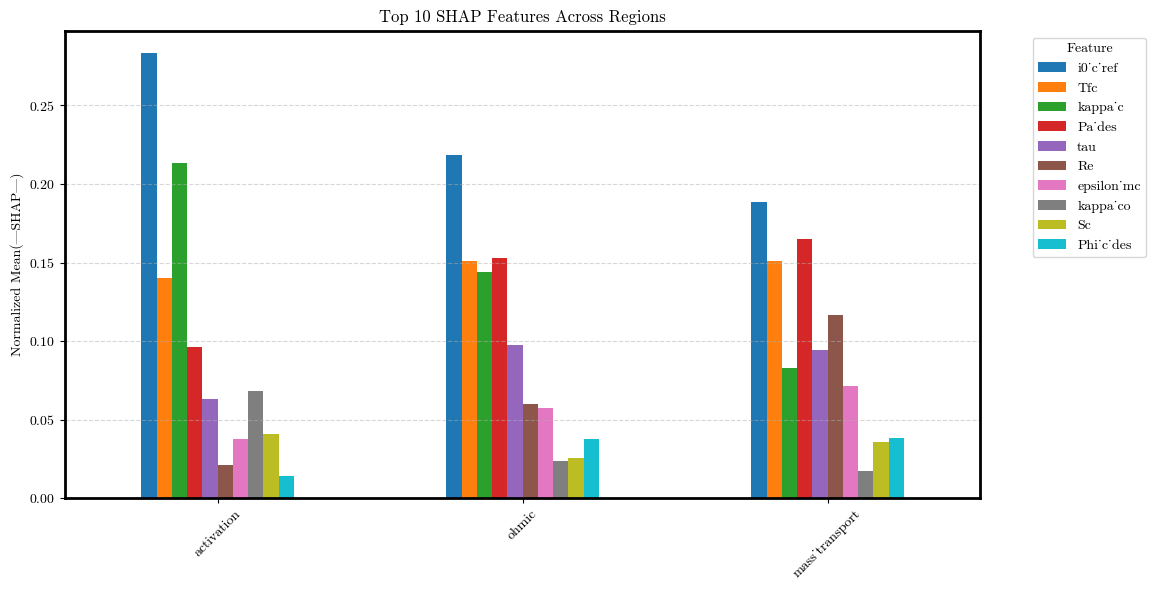

In [19]:
# Assuming you already computed these
shap_dfs = [shap_df_activation, shap_df_ohmic, shap_df_mass]
region_names = ["activation", "ohmic", "mass_transport"]

# 1. Visual comparison of SHAP rankings
plot_shap_comparison(shap_dfs, region_names, top_n=10)

In [20]:
# 2. Union of top 5 features per region
top_union = get_union_top_features(shap_dfs, top_k=5)
print("Union of top-5 SHAP features across all regions:")
print(sorted(top_union))

Union of top-5 SHAP features across all regions:
['Pa_des', 'Re', 'Tfc', 'i0_c_ref', 'kappa_c', 'kappa_co', 'tau']


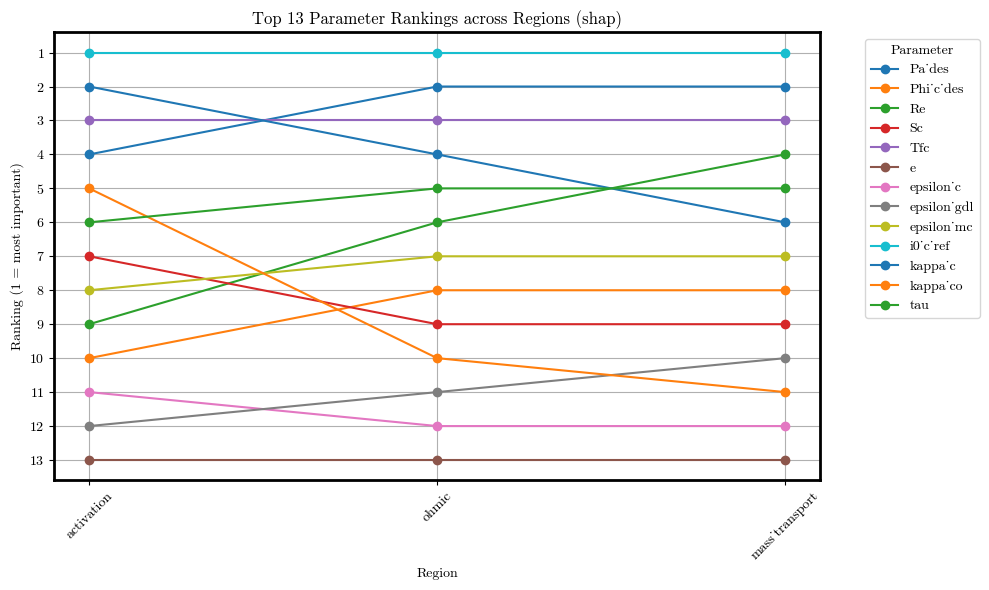

In [116]:
plot_top_k_rankings_across_regions(
    rank_sources={
        "activation": shap_df_activation,
        "ohmic": shap_df_ohmic,
        "mass_transport": shap_df_mass
    },
    source_type="shap",
    top_k=13
)

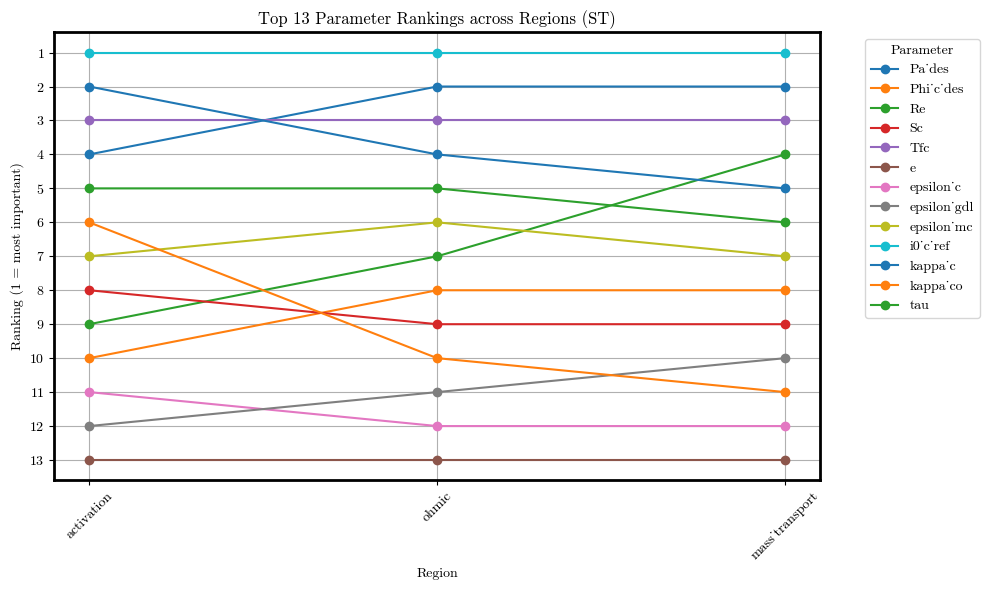

In [183]:
plot_top_k_rankings_across_regions(
    rank_sources={
        "activation": all_sobol_results_activation[8192]["sobol_df"],
        "ohmic": all_sobol_results_ohmic[8192]["sobol_df"],
        "mass_transport": all_sobol_results_mass[8192]["sobol_df"]
    },
    source_type="ST",
    top_k=13
)

In [109]:
select_top_features(
    rank_sources={
        "activation": shap_df_activation,
        "ohmic": shap_df_ohmic,
        "mass_transport": shap_df_mass
    },
    source_type="shap",
    method="topk",
    top_k=6
)


Region: activation
Selected 6 features using method='topk' (top_k=6)
Total importance explained: 0.862
Selected features: ['i0_c_ref', 'kappa_c', 'Tfc', 'Pa_des', 'kappa_co', 'tau']

Region: ohmic
Selected 6 features using method='topk' (top_k=6)
Total importance explained: 0.817
Selected features: ['i0_c_ref', 'Pa_des', 'Tfc', 'kappa_c', 'tau', 'Re']

Region: mass_transport
Selected 6 features using method='topk' (top_k=6)
Total importance explained: 0.798
Selected features: ['i0_c_ref', 'Pa_des', 'Tfc', 'Re', 'tau', 'kappa_c']

Union of all selected features across regions: ['Pa_des', 'Re', 'Tfc', 'i0_c_ref', 'kappa_c', 'kappa_co', 'tau']
Total unique features selected: 7


({'activation': ['i0_c_ref', 'kappa_c', 'Tfc', 'Pa_des', 'kappa_co', 'tau'],
  'ohmic': ['i0_c_ref', 'Pa_des', 'Tfc', 'kappa_c', 'tau', 'Re'],
  'mass_transport': ['i0_c_ref', 'Pa_des', 'Tfc', 'Re', 'tau', 'kappa_c']},
 {'Pa_des', 'Re', 'Tfc', 'i0_c_ref', 'kappa_c', 'kappa_co', 'tau'})

In [190]:
select_top_features(
    rank_sources={
        "activation": all_sobol_results_activation[2048]["sobol_df"],
        "ohmic": all_sobol_results_ohmic[2048]["sobol_df"],
        "mass_transport": all_sobol_results_mass[2048]["sobol_df"]
    },
    source_type="ST",
    method="threshold",
    threshold=0.9
)


Region: activation
Selected 5 features using method='threshold' (threshold=0.9)
Total importance explained: 0.927
Selected features: ['i0_c_ref', 'kappa_c', 'Tfc', 'Pa_des', 'tau']

Region: ohmic
Selected 6 features using method='threshold' (threshold=0.9)
Total importance explained: 0.911
Selected features: ['i0_c_ref', 'Pa_des', 'Tfc', 'kappa_c', 'tau', 'epsilon_mc']

Region: mass_transport
Selected 7 features using method='threshold' (threshold=0.9)
Total importance explained: 0.935
Selected features: ['i0_c_ref', 'Pa_des', 'Tfc', 'Re', 'kappa_c', 'tau', 'epsilon_mc']

Union of all selected features across regions: ['Pa_des', 'Re', 'Tfc', 'epsilon_mc', 'i0_c_ref', 'kappa_c', 'tau']
Total unique features selected: 7


({'activation': ['i0_c_ref', 'kappa_c', 'Tfc', 'Pa_des', 'tau'],
  'ohmic': ['i0_c_ref', 'Pa_des', 'Tfc', 'kappa_c', 'tau', 'epsilon_mc'],
  'mass_transport': ['i0_c_ref',
   'Pa_des',
   'Tfc',
   'Re',
   'kappa_c',
   'tau',
   'epsilon_mc']},
 {'Pa_des', 'Re', 'Tfc', 'epsilon_mc', 'i0_c_ref', 'kappa_c', 'tau'})

In [108]:
select_top_features(
    rank_sources={
        "activation": all_sobol_results_activation[2048]["sobol_df"],
        "ohmic": all_sobol_results_ohmic[2048]["sobol_df"],
        "mass_transport": all_sobol_results_mass[2048]["sobol_df"]
    },
    source_type="ST",
    method="threshold",
    threshold=0.9
)


Region: activation
Selected 5 features using method='threshold' (threshold=0.9)
Total importance explained: 0.927
Selected features: ['i0_c_ref', 'kappa_c', 'Tfc', 'Pa_des', 'tau']

Region: ohmic
Selected 6 features using method='threshold' (threshold=0.9)
Total importance explained: 0.911
Selected features: ['i0_c_ref', 'Pa_des', 'Tfc', 'kappa_c', 'tau', 'epsilon_mc']

Region: mass_transport
Selected 7 features using method='threshold' (threshold=0.9)
Total importance explained: 0.936
Selected features: ['i0_c_ref', 'Pa_des', 'Tfc', 'Re', 'tau', 'kappa_c', 'epsilon_mc']

Union of all selected features across regions: ['Pa_des', 'Re', 'Tfc', 'epsilon_mc', 'i0_c_ref', 'kappa_c', 'tau']
Total unique features selected: 7


({'activation': ['i0_c_ref', 'kappa_c', 'Tfc', 'Pa_des', 'tau'],
  'ohmic': ['i0_c_ref', 'Pa_des', 'Tfc', 'kappa_c', 'tau', 'epsilon_mc'],
  'mass_transport': ['i0_c_ref',
   'Pa_des',
   'Tfc',
   'Re',
   'tau',
   'kappa_c',
   'epsilon_mc']},
 {'Pa_des', 'Re', 'Tfc', 'epsilon_mc', 'i0_c_ref', 'kappa_c', 'tau'})

## Additional analysis

In [33]:
import xgboost as xgb
from typing import Tuple

def compute_mean_relative_error(
    model: xgb.XGBRegressor,
    data: pd.DataFrame,
    region_name: str,
    region_bounds: Tuple[float, float],
    input_cols: list,
    group_col: str = "config_id"
) -> Tuple[float, float]:
    """
    Compute the mean relative error and standard deviation for a trained model using 5-fold CV.

    Parameters
    ----------
    model : xgb.XGBRegressor
        Trained XGBoost model.
    data : pd.DataFrame
        DataFrame containing input features and polarization curve columns.
    region_name : str
        Name of the region (used to name the target column).
    region_bounds : tuple
        Current density bounds for the region.
    input_cols : list of str
        Input feature names.
    group_col : str
        Column name used for grouping in CV (e.g., config_id).

    Returns
    -------
    mean_rel_error : float
        Mean relative error.
    std_rel_error : float
        Standard deviation of the relative error.
    """
    df = data.copy()

    ifc_cols = [col for col in df.columns if col.startswith("ifc_")]
    ucell_cols = [col for col in df.columns if col.startswith("Ucell_")]

    target_col = f"AUC_{region_name}"
    df[target_col] = df.apply(
        compute_region_auc,
        axis=1,
        args=(ifc_cols, ucell_cols, region_bounds, "drop")
    )

    df = df.dropna(subset=[target_col])
    X = df[input_cols]
    y = df[target_col]
    groups = df[group_col]

    outer_cv = GroupKFold(n_splits=5)
    relative_errors = []

    for train_idx, test_idx in outer_cv.split(X, y, groups):
        X_test = X.iloc[test_idx]
        y_test = y.iloc[test_idx]
        y_pred = model.predict(X_test)
        rel_error = np.abs(y_test - y_pred) / y_test
        relative_errors.extend(rel_error)

    return np.mean(relative_errors), np.std(relative_errors)


In [27]:
mre, sd = compute_mean_relative_error(
    model=model_activation,
    data=valid_data,
    region_name="activation",
    region_bounds=REGIONS["activation"],
    input_cols=INPUT_COLUMNS
)
print(f"Mean Relative Error: {mre:.2%} ± {sd:.2%}")

Mean Relative Error: 1.56% ± 7.31%


In [24]:
mre, sd = compute_mean_relative_error(
    model=model_ohmic,
    data=valid_data,
    region_name="ohmic",
    region_bounds=REGIONS["ohmic"],
    input_cols=INPUT_COLUMNS
)
print(f"Mean Relative Error: {mre:.2%} ± {sd:.2%}")

Mean Relative Error: 7.37% ± 124.06%


In [34]:
mre, sd = compute_mean_relative_error(
    model=model_mass,
    data=valid_data,
    region_name="mass",
    region_bounds=REGIONS["mass_transport"],
    input_cols=INPUT_COLUMNS
)
print(f"Mean Relative Error: {mre:.2%} ± {sd:.2%}")

Mean Relative Error: 14.56% ± 290.58%


In [104]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd
import numpy as np

def plot_top_k_rankings_across_regions(rank_sources, source_type="shap", top_k=13, figsize=(10, 6)):
    """
    Plot parameter ranking changes across regions with improved formatting and sorted legend.

    Parameters
    ----------
    rank_sources : dict
        Maps region name → either SHAP df or Si dict.
        SHAP df must have 'feature' and 'mean_abs_shap'.
        Si dict must have 'feature' and 'S1' or 'ST'.
    source_type : str
        Either "shap", "S1", or "ST"
    top_k : int
        Max rank to include on the y-axis.
    figsize : tuple
        Size of the plot.
    """
    regions = list(rank_sources.keys())
    all_features = set()
    ranks_per_region = {}

    for region, data in rank_sources.items():
        if source_type == "shap":
            df = data.sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
            features = df["feature"].tolist()
        elif source_type in ["S1", "ST"]:
            scores = data[source_type]
            features = data["feature"]
            df = pd.DataFrame({"feature": features, "score": scores})
            df = df.sort_values("score", ascending=False).reset_index(drop=True)
            features = df["feature"].tolist()
        else:
            raise ValueError("Invalid source_type. Use 'shap', 'S1', or 'ST'.")

        all_features.update(features)
        ranks = {feat: i+1 for i, feat in enumerate(features)}
        ranks_per_region[region] = ranks

    all_features = sorted(all_features)
    region_labels = list(rank_sources.keys())

    # Build ranking matrix
    ranking_matrix = pd.DataFrame(index=all_features, columns=region_labels)
    for region in region_labels:
        for feat in all_features:
            ranking_matrix.loc[feat, region] = ranks_per_region[region].get(feat, np.nan)

    # Keep only features that appear in top_k in at least one region
    filtered = ranking_matrix.apply(lambda row: any(r <= top_k for r in row if pd.notna(r)), axis=1)
    ranking_matrix = ranking_matrix[filtered]

    # Sort features by their rank in the last region (for legend)
    last_region = region_labels[-1]
    ranking_matrix["__sort_key__"] = ranking_matrix[last_region]
    ranking_matrix = ranking_matrix.sort_values("__sort_key__")
    ranking_matrix = ranking_matrix.drop(columns="__sort_key__")

    # Color palette
    n_features = len(ranking_matrix)
    cmap = cm.get_cmap("tab20", n_features)
    colors = [cmap(i) for i in range(n_features)]

    # Plot
    plt.figure(figsize=figsize)
    for i, (feature, row) in enumerate(ranking_matrix.iterrows()):
        y_vals = row.values.astype(float)
        plt.plot(region_labels, y_vals, marker='o', label=feature, color=colors[i])

    plt.gca().invert_yaxis()
    plt.xticks(rotation=45, fontsize=12)
    plt.yticks(range(1, top_k + 1), fontsize=12)
    plt.xlabel("Region", fontsize=14)
    plt.ylabel("Ranking (1 = most important)", fontsize=14)
    plt.title(f"Top {top_k} Parameter Rankings across Regions ({source_type})", fontsize=16)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Parameter", fontsize=11, title_fontsize=12)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


C:\Users\User\AppData\Local\Temp\ipykernel_9652\757954618.py:65: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", n_features)


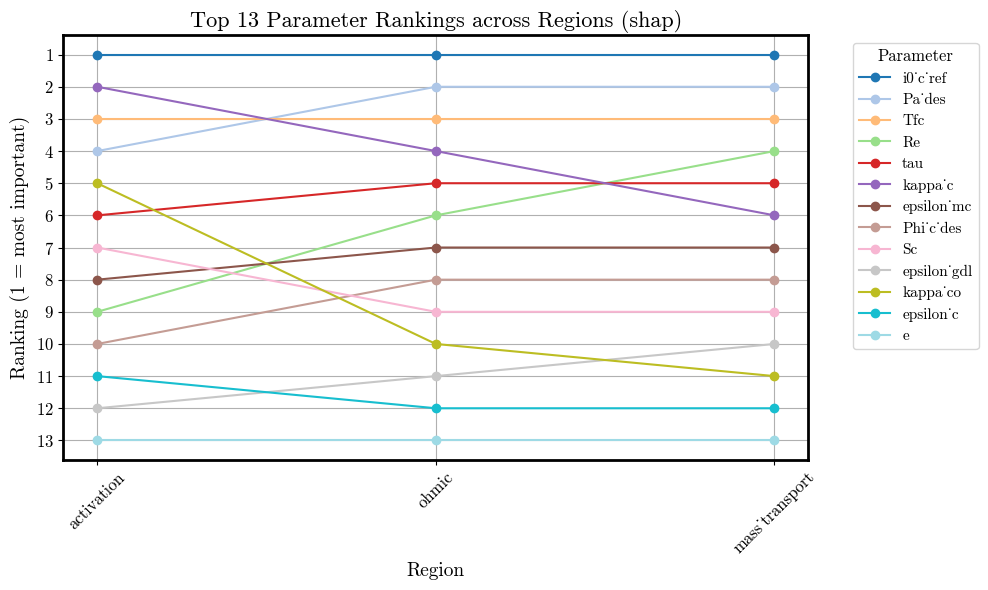

In [105]:
plot_top_k_rankings_across_regions(
    rank_sources={
        "activation": shap_df_activation,
        "ohmic": shap_df_ohmic,
        "mass_transport": shap_df_mass
    },
    source_type="shap",
    top_k=13
)

C:\Users\User\AppData\Local\Temp\ipykernel_9652\757954618.py:65: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", n_features)


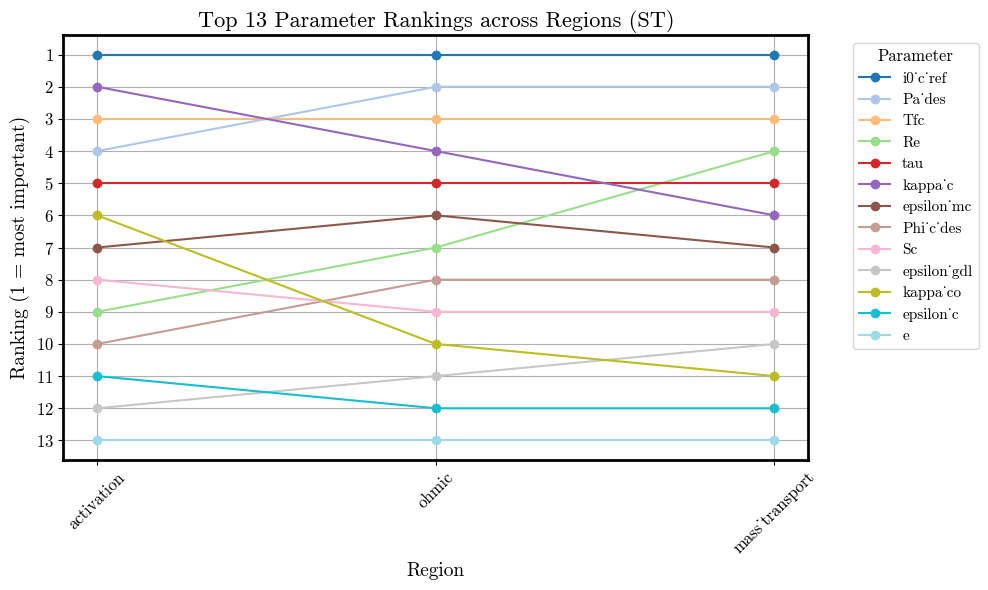

In [106]:
plot_top_k_rankings_across_regions(
    rank_sources={
        "activation": all_sobol_results_activation[8192]["sobol_df"],
        "ohmic": all_sobol_results_ohmic[8192]["sobol_df"],
        "mass_transport": all_sobol_results_mass[8192]["sobol_df"]
    },
    source_type="ST",
    top_k=13
)

## Reliability of SHAP

In [38]:
def compute_bootstrapped_shap(
    model, X_full, n_bootstrap=30, sample_frac=0.5, random_state=42
):
    np.random.seed(random_state)
    shap_values_list = []

    for i in range(n_bootstrap):
        X_sample = X_full.sample(frac=sample_frac, replace=True)
        explainer = shap.Explainer(model)
        shap_values = explainer(X_sample)
        mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
        shap_values_list.append(mean_abs_shap)

    shap_array = np.stack(shap_values_list)
    shap_mean = shap_array.mean(axis=0)
    shap_std = shap_array.std(axis=0)
    shap_ci = 1.96 * shap_std / np.sqrt(n_bootstrap)  # 95% CI

    df = pd.DataFrame({
        "feature": X_full.columns,
        "mean_abs_shap": shap_mean,
        "ci_95": shap_ci
    }).sort_values("mean_abs_shap", ascending=False)

    return df

In [ ]:
X = valid_data[INPUT_COLUMNS]  # same as in your project
shap_summary_df = compute_bootstrapped_shap(model_ohmic, X)

In [ ]:

def plot_bootstrapped_shap(df, top_n=10):
    top = df.head(top_n)
    plt.figure(figsize=(8, 5))
    plt.barh(top["feature"][::-1], top["mean_abs_shap"][::-1],
             xerr=top["ci_95"][::-1], capsize=4)
    plt.xlabel("Mean(|SHAP value|)")
    plt.title("SHAP Feature Importance with 95% CI")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
plot_bootstrapped_shap(shap_summary_df, top_n = 13)